# PS3 — Détection d'anomalies par réseaux siamois
## Parties 1 à 5 + Conv1D + Conv2D (GASF & GADF × 224 · 512 · 1024)

**Dataset :** SUBF-V2.0 — Bearing Faults Sound Data
**Modes :** Normal · IRF · ORF

---
### Pipeline
```
Signaux → Normalisation → PAA → GASF/GADF (3 tailles)
                               → Conv1D  (Contrastive Loss + Euclidienne)
                               → Conv2D  (Triplet Loss + Cosinus)
                               → Comparaison finale
```

---
## Étape 1 — Monter Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Étape 2 — Extraire le dataset

In [8]:
import os

# Lister le contenu de MyDrive
print("Contenu de MyDrive :")
for f in os.listdir('/content/drive/MyDrive'):
    print(f"  {f}")

Contenu de MyDrive :
  archive.zip


In [9]:
import zipfile, os

zip_path     = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print('Extraction OK ✅')

Extraction OK ✅


---
## Étape 3 — Installer les librairies

In [10]:
!pip install -q pyts opencv-python matplotlib pandas numpy tensorflow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.3 MB/s eta 0:00:00


---
## Étape 4 — Imports & Constantes

In [11]:
import os, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2, gc
import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    roc_curve, auc, classification_report,
    precision_recall_fscore_support
)
from pyts.image import GramianAngularField

SEED      = 42
PAA_SIZE  = 224
MARGIN_C  = 1.0    # Contrastive Loss (Conv1D)
MARGIN_T  = 0.3    # Triplet Loss     (Conv2D)
EPOCHS    = 50
DRIVE     = '/content/drive/MyDrive/'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.makedirs(DRIVE, exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU : {gpus[0].name} ✅')
print(f'TensorFlow : {tf.__version__} ✅')

GPU : /physical_device:GPU:0 ✅
TensorFlow : 2.20.0 ✅


---
## Étape 5 — Vérification structure dataset

In [12]:
for root, dirs, files in os.walk('/content/dataset'):
    level  = root.replace('/content/dataset', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/  ({len(files)} fichiers)')

dataset/  (0 fichiers)
  Dataset/  (0 fichiers)
    Normal/  (2160 fichiers)
    Inner Race Fault/  (2160 fichiers)
    Outer Race Fault/  (2160 fichiers)


---
## Étape 6 — Chargement des signaux (100 par classe)

In [13]:
def load_signals(folder, n_samples=100):
    files    = [f for f in os.listdir(folder) if f.endswith('.csv')]
    print(f'{os.path.basename(folder)} → {len(files)} fichiers')
    if len(files) == 0:
        return []
    selected = random.sample(files, min(n_samples, len(files)))
    signals  = []
    for fname in selected:
        try:
            data   = pd.read_csv(os.path.join(folder, fname), header=None)
            signal = data.values.flatten().astype(np.float32)
            signals.append(signal)
        except Exception as e:
            print(f'  Erreur {fname}: {e}')
    return signals

normal = load_signals('/content/dataset/Dataset/Normal')
irf    = load_signals('/content/dataset/Dataset/Inner Race Fault')
orf    = load_signals('/content/dataset/Dataset/Outer Race Fault')

print(f'\nNormal:{len(normal)} | IRF:{len(irf)} | ORF:{len(orf)}')
print(f"Longueur d'un signal : {len(normal[0])} points")

Normal → 2160 fichiers
Inner Race Fault → 2160 fichiers
Outer Race Fault → 2160 fichiers

Normal:100 | IRF:100 | ORF:100
Longueur d'un signal : 100000 points


---
## Étape 7 — Visualisation des signaux bruts

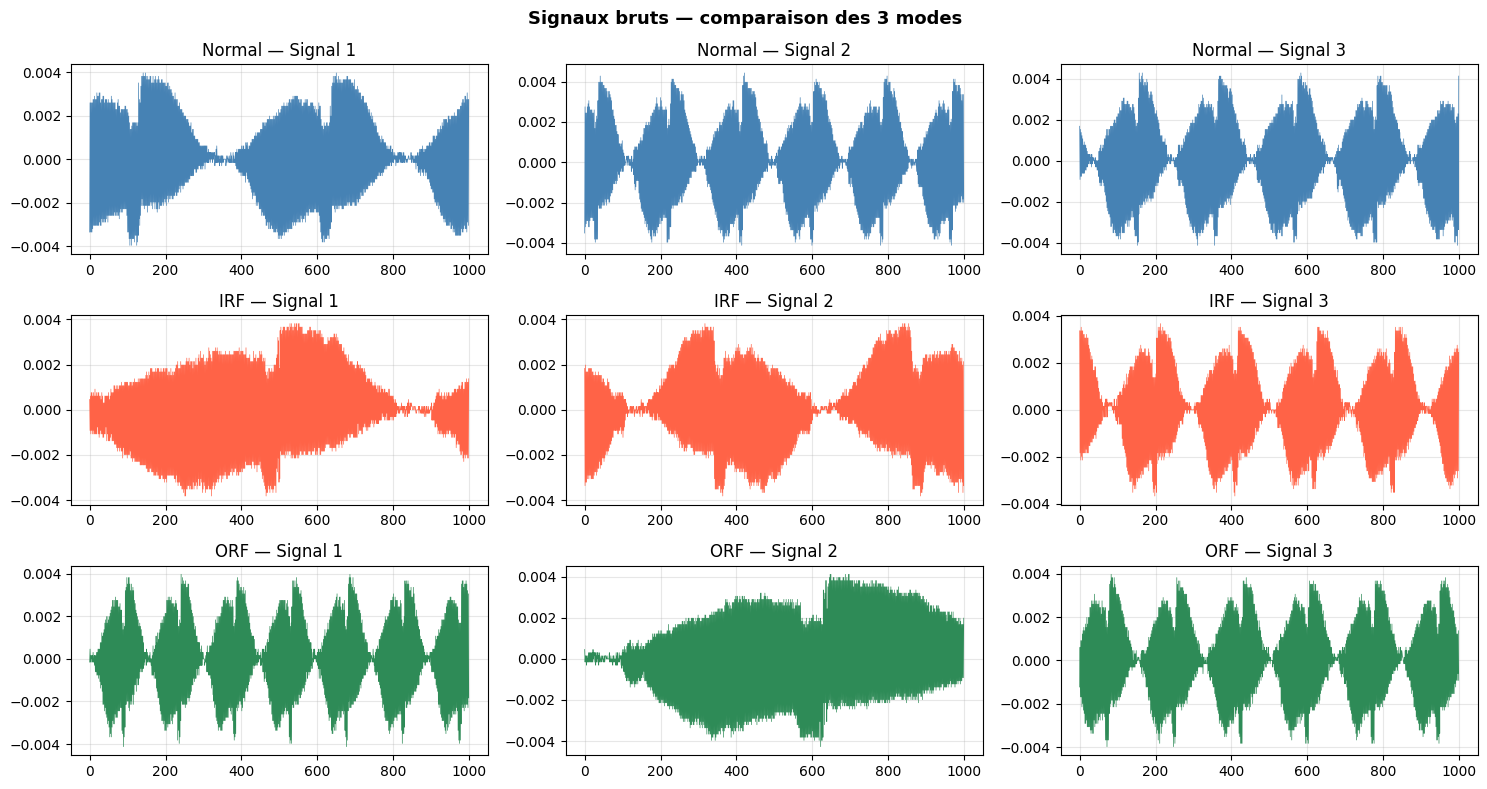

✅ Figure sauvegardée


In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
colors = {'Normal':'steelblue', 'IRF':'tomato', 'ORF':'seagreen'}

for row, (name, signals) in enumerate([('Normal',normal),('IRF',irf),('ORF',orf)]):
    for col in range(3):
        step = max(1, len(signals[col]) // 1000)
        axes[row, col].plot(signals[col][::step], linewidth=0.5, color=colors[name])
        axes[row, col].set_title(f'{name} — Signal {col+1}')
        axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Signaux bruts — comparaison des 3 modes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DRIVE + '01_signaux_bruts.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardée')

---
## Étape 8 — Normalisation [0,1] ligne par ligne

> ✅ Conforme au prof : normalisation par signal (pas par colonne)

In [15]:
def normalize_signals(signals):
    normalized = []
    for s in signals:
        min_val = np.min(s)
        max_val = np.max(s)
        if max_val - min_val == 0:
            normalized.append(s)
        else:
            normalized.append((s - min_val) / (max_val - min_val))
    return normalized

normal_norm = normalize_signals(normal)
irf_norm    = normalize_signals(irf)
orf_norm    = normalize_signals(orf)

print(f'Min après normalisation : {np.min(normal_norm[0]):.4f}')
print(f'Max après normalisation : {np.max(normal_norm[0]):.4f}')
print('✅ Normalisation [0,1] correcte')

Min après normalisation : 0.0000
Max après normalisation : 1.0000
✅ Normalisation [0,1] correcte


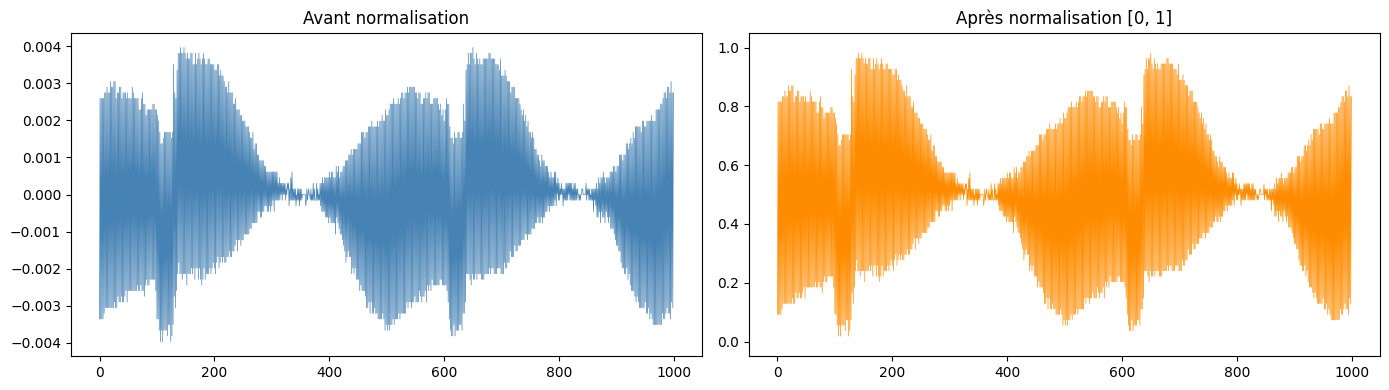

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
step = max(1, len(normal[0]) // 1000)
axes[0].plot(normal[0][::step],      linewidth=0.5, color='steelblue')
axes[0].set_title('Avant normalisation')
axes[1].plot(normal_norm[0][::step], linewidth=0.5, color='darkorange')
axes[1].set_title('Après normalisation [0, 1]')
axes[1].set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(DRIVE + '02_normalisation.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Étape 9 — Sauvegarde CSV (Base 1D)

In [17]:
def save_to_csv(signals, filename):
    max_len = max(len(s) for s in signals)
    padded  = []
    for s in signals:
        if len(s) < max_len:
            s = np.pad(s, (0, max_len - len(s)))
        padded.append(s)
    df = pd.DataFrame(padded)
    df.to_csv(filename, index=False)
    print(f'✅ Sauvegardé : {filename} — shape : {df.shape}')

save_to_csv(normal_norm, DRIVE + 'normal_norm.csv')
save_to_csv(irf_norm,    DRIVE + 'irf_norm.csv')
save_to_csv(orf_norm,    DRIVE + 'orf_norm.csv')
print('\nBase 1D sauvegardée sur Drive ✅')

✅ Sauvegardé : /content/drive/MyDrive/normal_norm.csv — shape : (100, 100000)
✅ Sauvegardé : /content/drive/MyDrive/irf_norm.csv — shape : (100, 100000)
✅ Sauvegardé : /content/drive/MyDrive/orf_norm.csv — shape : (100, 100000)

Base 1D sauvegardée sur Drive ✅


---
## Étape 10 — PAA : 100 000 → 224 points

> PAA divise le signal en 224 segments et prend la moyenne de chaque segment.  
> Ratio 1:1 avec image_size=224 → images parfaitement lisibles.

In [18]:
def apply_paa_numpy(signals, paa_size):
    """
    PAA manuel NumPy.
    paa_size doit correspondre à la taille de l'image cible
    pour garantir un ratio 1:1 (ex: 224 pour image 224×224).
    """
    reduced = []
    for s in signals:
        seg_len = len(s) // paa_size
        s_trunc = s[:paa_size * seg_len]
        s_paa   = s_trunc.reshape(paa_size, seg_len).mean(axis=1).astype(np.float32)
        s_min, s_max = s_paa.min(), s_paa.max()
        if s_max - s_min > 0:
            s_paa = (s_paa - s_min) / (s_max - s_min)
        reduced.append(s_paa)
    return reduced

# Vérification pour les 3 tailles
for size in [224, 512, 1024]:
    test = apply_paa_numpy(normal_norm, paa_size=size)
    assert len(test[0]) == size
    print(f'PAA {size} → {len(test[0])} points ✅')

# PAA 224 stocké pour Conv1D
normal_paa = apply_paa_numpy(normal_norm, paa_size=224)
irf_paa    = apply_paa_numpy(irf_norm,    paa_size=224)
orf_paa    = apply_paa_numpy(orf_norm,    paa_size=224)
print(f'Avant PAA : {len(normal_norm[0])} points')
print(f'Après PAA : {len(normal_paa[0])} points ✅')

PAA 224 → 224 points ✅
PAA 512 → 512 points ✅
PAA 1024 → 1024 points ✅
Avant PAA : 100000 points
Après PAA : 224 points ✅


---
## Étape 11 — Génération GASF/GADF PAA (3 tailles)

> ✅ Conversion [0,1] → [-1,1] avant GASF (requis par arccos)  
> ✅ Encodage image correct : (x+1)*127.5

In [19]:
def generate_gaf_paa(signals, method, size, folder):
    """
    Génère 1 image GAF par signal.
    method : 'summation' (GASF) ou 'difference' (GADF)
    size   : doit correspondre à len(signals[0]) → ratio 1:1
    """
    os.makedirs(folder, exist_ok=True)
    gaf = GramianAngularField(image_size=size, method=method)

    for i, s in enumerate(signals):
        s_scaled = (2 * np.array(s, dtype=np.float32) - 1).reshape(1, -1)
        X   = gaf.fit_transform(s_scaled)
        img = ((X[0] + 1) * 127.5).astype(np.uint8)
        cv2.imwrite(f'{folder}/img_{i:03d}.png', img)

    print(f'  {folder} → {len(signals)} images ✅')


# Génération GASF + GADF pour les 3 tailles
for size in [224, 512, 1024]:
    print(f'\n=== Génération PAA {size}×{size} ===')

    n_paa = apply_paa_numpy(normal_norm, paa_size=size)
    i_paa = apply_paa_numpy(irf_norm,    paa_size=size)
    o_paa = apply_paa_numpy(orf_norm,    paa_size=size)

    print(f'  Signal réduit : {len(n_paa[0])} points → image {size}×{size}')

    for method, tag in [('summation','GASF'), ('difference','GADF')]:
        for cls, data in [('normal',n_paa),('irf',i_paa),('orf',o_paa)]:
            generate_gaf_paa(data, method, size, f'/content/{tag}_{size}_paa/{cls}')

    print(f'✅ {size}×{size} terminé')


=== Génération PAA 224×224 ===
  Signal réduit : 224 points → image 224×224
  /content/GASF_224_paa/normal → 100 images ✅
  /content/GASF_224_paa/irf → 100 images ✅
  /content/GASF_224_paa/orf → 100 images ✅
  /content/GADF_224_paa/normal → 100 images ✅
  /content/GADF_224_paa/irf → 100 images ✅
  /content/GADF_224_paa/orf → 100 images ✅
✅ 224×224 terminé

=== Génération PAA 512×512 ===
  Signal réduit : 512 points → image 512×512
  /content/GASF_512_paa/normal → 100 images ✅
  /content/GASF_512_paa/irf → 100 images ✅
  /content/GASF_512_paa/orf → 100 images ✅
  /content/GADF_512_paa/normal → 100 images ✅
  /content/GADF_512_paa/irf → 100 images ✅
  /content/GADF_512_paa/orf → 100 images ✅
✅ 512×512 terminé

=== Génération PAA 1024×1024 ===
  Signal réduit : 1024 points → image 1024×1024
  /content/GASF_1024_paa/normal → 100 images ✅
  /content/GASF_1024_paa/irf → 100 images ✅
  /content/GASF_1024_paa/orf → 100 images ✅
  /content/GADF_1024_paa/normal → 100 images ✅
  /content/GADF_10

---
## Étape 12 — Validation images générées

In [20]:
print(f"{'Config':<22} {'Normal':>8} {'IRF':>8} {'ORF':>8}  Status")
print('-' * 55)
all_ok = True
for method in ['GASF', 'GADF']:
    for size in [224, 512, 1024]:
        counts = []
        for cls in ['normal', 'irf', 'orf']:
            folder = f'/content/{method}_{size}_paa/{cls}'
            n = len(os.listdir(folder)) if os.path.exists(folder) else 0
            counts.append(n)
        ok = all(c == 100 for c in counts)
        if not ok: all_ok = False
        print(f'  {method}_{size}_paa{"":<6} {counts[0]:>8} {counts[1]:>8} {counts[2]:>8}  {"✅" if ok else "❌"}')
print()
print('✅ Toutes les images OK' if all_ok else '❌ Certaines images manquent')

Config                   Normal      IRF      ORF  Status
-------------------------------------------------------
  GASF_224_paa            100      100      100  ✅
  GASF_512_paa            100      100      100  ✅
  GASF_1024_paa            100      100      100  ✅
  GADF_224_paa            100      100      100  ✅
  GADF_512_paa            100      100      100  ✅
  GADF_1024_paa            100      100      100  ✅

✅ Toutes les images OK


---
## Étape 13 — Visualisation GASF vs GADF par classe

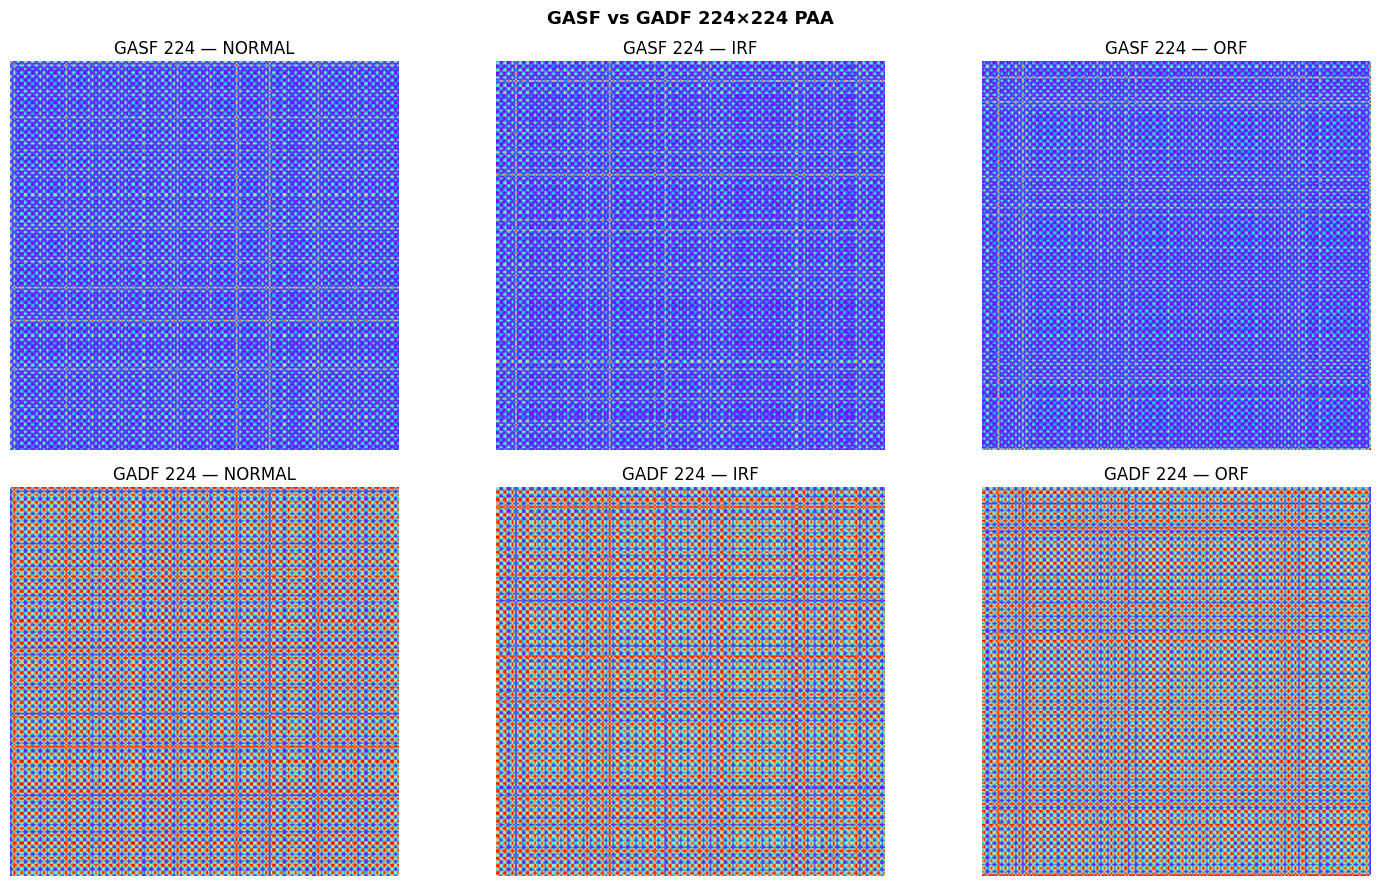

✅ Figure sauvegardée


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for j, cls in enumerate(['normal', 'irf', 'orf']):
    ig = cv2.imread(f'/content/GASF_224_paa/{cls}/img_000.png', cv2.IMREAD_GRAYSCALE)
    id_ = cv2.imread(f'/content/GADF_224_paa/{cls}/img_000.png', cv2.IMREAD_GRAYSCALE)
    if ig is not None:  axes[0,j].imshow(ig,  cmap='rainbow')
    if id_ is not None: axes[1,j].imshow(id_, cmap='rainbow')
    axes[0,j].set_title(f'GASF 224 — {cls.upper()}'); axes[0,j].axis('off')
    axes[1,j].set_title(f'GADF 224 — {cls.upper()}'); axes[1,j].axis('off')
plt.suptitle('GASF vs GADF 224×224 PAA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DRIVE + '03_gasf_gadf_224.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Figure sauvegardée')

---
## Étape 14 — Sauvegarde Drive

In [22]:
for method in ['GASF', 'GADF']:
    for size in [224, 512, 1024]:
        src  = f'/content/{method}_{size}_paa'
        dest = DRIVE + f'{method}_{size}_paa'
        if os.path.exists(src):
            shutil.copytree(src, dest, dirs_exist_ok=True)
            print(f'✅ {method}_{size}_paa → Drive')
print('\n✅ Toutes les images sauvegardées sur Drive')

✅ GASF_224_paa → Drive
✅ GASF_512_paa → Drive
✅ GASF_1024_paa → Drive
✅ GADF_224_paa → Drive
✅ GADF_512_paa → Drive
✅ GADF_1024_paa → Drive

✅ Toutes les images sauvegardées sur Drive


---
# Fonctions partagées — Conv1D & Conv2D

In [23]:
# ── Chargement images ─────────────────────────────────────────────────────────
def load_images_folder(folder, image_size):
    images = []
    files  = sorted([f for f in os.listdir(folder) if f.endswith('.png')])
    for fname in files:
        img = load_img(os.path.join(folder, fname),
                       color_mode='grayscale',
                       target_size=(image_size, image_size))
        images.append(img_to_array(img) / 255.0)
    return np.array(images, dtype=np.float32)


# ── Courbes d'apprentissage ───────────────────────────────────────────────────
def plot_learning_curves(history, model_name):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history['loss'],     label='Train Loss', color='steelblue')
    ax.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
    ax.set_xlabel('Époque'); ax.set_ylabel('Loss')
    ax.set_title(f"Courbes d'apprentissage — {model_name}")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = model_name.lower().replace(' ','_').replace('/','_').replace('×','x')
    plt.savefig(DRIVE + f'{fname}_learning.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Figure sauvegardée')


# ── Interprétation ────────────────────────────────────────────────────────────
def interpret_results(acc, f1, roc_auc, model_name):
    print(f"\n{'='*52}")
    print(f'  INTERPRÉTATION — {model_name}')
    print(f"{'='*52}")
    for metric, name in [(acc,'Accuracy'),(f1,'F1-score'),(roc_auc,'AUC     ')]:
        if metric >= 0.90:   status = '✅ Excellent'
        elif metric >= 0.80: status = '✅ Bon'
        elif metric >= 0.70: status = '⚠️  Acceptable'
        else:                status = '❌ Insuffisant'
        print(f'  {name} : {metric:.4f}  →  {status}')
    print(f"{'='*52}")
    if roc_auc < 0.70:
        print('  ⚠️  → Vérifier que les images sont bien générées avec PAA')


print('Fonctions partagées OK ✅')

Fonctions partagées OK ✅


*texte en italique*# PS3 — Détection d'anomalies par réseaux siamois
## Parties : Théorie, Implémentation, Évaluation & Conclusion

Principe des Réseaux Siamois

Un *réseau siamois* est une architecture composée de *deux sous-réseaux identiques* partageant les mêmes poids. Chaque branche produit un *embedding* (vecteur de représentation), et la décision finale est prise en mesurant la distance entre ces deux embeddings.

  Entrée A ──► [Réseau f(θ)] ──► Embedding A ─┐
                   ↕ poids partagés            ├──► Distance d(A,B) ──► Décision
  Entrée B ──► [Réseau f(θ)] ──► Embedding B ─┘

*Avantages clés :*
- *Few-shot learning* : fonctionne avec peu d'exemples par classe
- *Généralisation* : peut reconnaître des classes nouvelles sans ré-entraînement
- *Robustesse* : insensible aux déséquilibres de classes

 Partage des Poids (Weight Sharing)

Les deux branches utilisent la *même fonction* $f_\theta$ :
$$e_A = f_\theta(x_A) \qquad e_B = f_\theta(x_B)$$

Les gradients des deux branches sont *sommés* lors de la rétropropagation, mettant à jour un seul ensemble de poids $\theta$.

*Pourquoi partager les poids ?*
1. *Symétrie* : garantit $d(x_A, x_B) = d(x_B, x_A)$
2. *Réduction des paramètres* : divise par deux le nombre de paramètres
3. *Cohérence de l'espace d'embedding* : les deux entrées sont projetées dans le même espace latent
4. *Régularisation implicite* : prévient le surapprentissage

 Apprentissage de Similarité et Création des Paires

L'objectif est d'apprendre une *métrique de similarité* :
- *Paire similaire* (label = 0) : deux signaux de la *même classe* → distance doit être *petite*
- *Paire dissimilaire* (label = 1) : deux signaux de *classes différentes* → distance doit être *grande*

Dans ce projet : classes Normal (0), Inner Race Fault (1), Outer Race Fault (2). On vise un *équilibre 50/50* similaires/dissimilaires.

 Espace d'Embedding

L'*espace d'embedding* $\mathbb{R}^d$ doit satisfaire :
- *Compacité intra-classe* : les exemples d'une même classe sont regroupés
- *Séparabilité inter-classe* : les clusters de classes différentes sont éloignés

| Dimension | Usage typique |
|-----------|---------------|
| 32–64     | Petits datasets, signaux courts |
| 128–256   | Données complexes, images |
| 512+      | Grandes bases, vision |

→ *128 dimensions* pour les deux modèles dans ce projet.

 Apprentissage Métrique et Fonctions de Perte

### Distance Euclidienne
$$d_E(a, b) = \|a - b\|_2 = \sqrt{\sum_{i=1}^d (a_i - b_i)^2}$$

### Distance Cosinus
$$d_{\cos}(a, b) = 1 - \frac{a \cdot b}{\|a\|_2 \cdot \|b\|_2}$$

### Contrastive Loss (utilisée dans ce projet)
$$\mathcal{L}_{CL} = (1 - y) \cdot \frac{1}{2} d^2 + y \cdot \frac{1}{2} \max(0, m - d)^2$$
- $y=0$ (similaire) : minimise $d$ (rapproche les similaires)
- $y=1$ (dissimilaire) : pénalise si $d < m$ (éloigne les dissimilaires)
- $m$ = marge (hyperparamètre, typiquement $m = 1.0$)

### Triplet Loss (alternative plus puissante)
$$\mathcal{L}_{TL} = \max(0, d(a,p) - d(a,n) + m)$$
Avec un triplet $(a, p, n)$ : anchor, positive (même classe), negative (classe différente).

---
# Partie 7.1 — Réseau Siamois Conv1D
## Signaux temporels PAA + Contrastive Loss + Distance Euclidienne

In [24]:
# ── Contrastive Loss ──────────────────────────────────────────────────────────
def contrastive_loss(margin=MARGIN_C):
    """
    y=0 → similaire  : minimise distance euclidienne
    y=1 → dissimilaire : maximise jusqu'à la marge
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        d      = tf.squeeze(y_pred, axis=-1)
        sim    = (1 - y_true) * K.square(d)
        disim  = y_true * K.square(K.maximum(margin - d, 0))
        return K.mean(sim + disim) / 2
    return loss


# ── Modèle siamois générique (distance euclidienne) ───────────────────────────
def build_siamese_contrastive(encoder, input_shape, name='siamese'):
    inp_a    = layers.Input(shape=input_shape, name='input_a')
    inp_b    = layers.Input(shape=input_shape, name='input_b')
    emb_a    = encoder(inp_a)
    emb_b    = encoder(inp_b)
    distance = layers.Lambda(
        lambda x: K.sqrt(K.sum(K.square(x[0]-x[1]), axis=1, keepdims=True) + K.epsilon()),
        name='euclidean_distance'
    )([emb_a, emb_b])
    return Model([inp_a, inp_b], distance, name=name)


# ── Création paires ───────────────────────────────────────────────────────────
def create_pairs(class_data, n_pairs_per_type=500, seed=SEED):
    random.seed(seed)
    classes = list(class_data.keys())
    pairs_A, pairs_B, labels = [], [], []
    for cls in classes:
        sigs = class_data[cls]
        for _ in range(n_pairs_per_type):
            i, j = random.sample(range(len(sigs)), 2)
            pairs_A.append(sigs[i]); pairs_B.append(sigs[j]); labels.append(0)
    for _ in range(n_pairs_per_type * len(classes)):
        cls_a, cls_b = random.sample(classes, 2)
        i = random.randint(0, len(class_data[cls_a])-1)
        j = random.randint(0, len(class_data[cls_b])-1)
        pairs_A.append(class_data[cls_a][i])
        pairs_B.append(class_data[cls_b][j])
        labels.append(1)
    combined = list(zip(pairs_A, pairs_B, labels))
    random.shuffle(combined)
    pairs_A, pairs_B, labels = zip(*combined)
    return (
        np.array(pairs_A, dtype=np.float32),
        np.array(pairs_B, dtype=np.float32),
        np.array(labels,  dtype=np.float32)
    )


# ── Split paires ──────────────────────────────────────────────────────────────
def split_pairs(pA, pB, lb):
    A_tr,A_tmp,B_tr,B_tmp,y_tr,y_tmp = train_test_split(
        pA, pB, lb, test_size=0.30, random_state=SEED, stratify=lb)
    A_v,A_te,B_v,B_te,y_v,y_te = train_test_split(
        A_tmp,B_tmp,y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)
    return A_tr,B_tr,y_tr, A_v,B_v,y_v, A_te,B_te,y_te


# ── Évaluation Conv1D (Contrastive + Euclidienne) ─────────────────────────────
def evaluate_contrastive(model, A_test, B_test, y_test, model_name):
    distances = model.predict([A_test, B_test], verbose=0).squeeze()
    fpr, tpr, thresholds = roc_curve(y_test, distances)
    roc_auc   = auc(fpr, tpr)
    opt_idx   = np.argmax(tpr - fpr)
    threshold = thresholds[opt_idx]
    y_pred    = (distances >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{'='*52}")
    print(f'  ÉVALUATION — {model_name}')
    print(f"{'='*52}")
    print(f'  Seuil optimal : {threshold:.4f}')
    print(f'  Accuracy      : {acc*100:.2f}%')
    print(f'  F1-score      : {f1:.4f}')
    print(f'  AUC           : {roc_auc:.4f}')
    print(f"{'='*52}")
    print()
    print(classification_report(y_test, y_pred,
          target_names=['Similaire (0)', 'Dissimilaire (1)']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    cm = confusion_matrix(y_test, y_pred)
    im = axes[0,0].imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=axes[0,0])
    for i in range(2):
        for j in range(2):
            axes[0,0].text(j, i, f"{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)",
                           ha='center', va='center', fontsize=12, fontweight='bold',
                           color='white' if cm[i,j]>cm.max()/2 else 'black')
    axes[0,0].set_xticks([0,1]); axes[0,0].set_xticklabels(['Sim prédit','Dissim prédit'], rotation=15)
    axes[0,0].set_yticks([0,1]); axes[0,0].set_yticklabels(['Sim réel','Dissim réel'])
    axes[0,0].set_title(f'Matrice de confusion\nAccuracy={acc*100:.2f}%', fontweight='bold')

    axes[0,1].plot(fpr, tpr, color='steelblue', lw=2.5, label=f'AUC={roc_auc:.4f}')
    axes[0,1].plot([0,1],[0,1],'k--',lw=1, label='Hasard')
    axes[0,1].scatter(fpr[opt_idx], tpr[opt_idx], color='tomato', s=120, zorder=5,
                      label=f'Seuil={threshold:.3f}')
    axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
    axes[0,1].set_title(f'Courbe ROC\nAUC={roc_auc:.4f}', fontweight='bold')
    axes[0,1].legend(loc='lower right'); axes[0,1].grid(True, alpha=0.3)

    d_sim   = distances[y_test==0]
    d_disim = distances[y_test==1]
    axes[1,0].hist(d_sim,   bins=40, alpha=0.7, color='steelblue', label=f'Similaires (moy={d_sim.mean():.3f})')
    axes[1,0].hist(d_disim, bins=40, alpha=0.7, color='tomato',    label=f'Dissimilaires (moy={d_disim.mean():.3f})')
    axes[1,0].axvline(threshold, color='black', linestyle='--', lw=2, label=f'Seuil={threshold:.3f}')
    axes[1,0].set_xlabel('Distance euclidienne')
    axes[1,0].set_title('Distribution des distances', fontweight='bold')
    axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

    prec, rec, f1s, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0,1])
    x = np.arange(2); w = 0.25
    b1 = axes[1,1].bar(x-w, prec, width=w, label='Précision', color='steelblue', alpha=0.85)
    b2 = axes[1,1].bar(x,   rec,  width=w, label='Rappel',    color='seagreen',  alpha=0.85)
    b3 = axes[1,1].bar(x+w, f1s,  width=w, label='F1',        color='tomato',    alpha=0.85)
    for bars in [b1,b2,b3]:
        for bar in bars:
            h = bar.get_height()
            axes[1,1].text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=9)
    axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(['Similaire','Dissimilaire'])
    axes[1,1].set_ylim(0,1.15)
    axes[1,1].set_title('Précision / Rappel / F1', fontweight='bold')
    axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Évaluation — {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = model_name.lower().replace(' ','_').replace('/','_').replace('×','x')
    plt.savefig(DRIVE + f'{fname}_evaluation.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Figures sauvegardées')
    return acc, f1, roc_auc


print('Fonctions Conv1D OK ✅')

Fonctions Conv1D OK ✅


In [25]:
# ── Fenêtrage 8192 pts pour Conv1D ───────────────────────────────────────────
WINDOW_SIZE = 8192  # 8× plus riche que 1024, safe sur Colab

def extract_windows(signals, window_size=WINDOW_SIZE, n_windows=5, seed=SEED):
    """
    Extrait n_windows fenêtres aléatoires par signal.
    Chaque fenêtre renormalisée dans [0,1].
    100 signaux × 5 fenêtres = 500 signaux/classe
    """
    random.seed(seed)
    all_windows = []
    for s in signals:
        s = np.array(s, dtype=np.float32)
        for _ in range(n_windows):
            if len(s) <= window_size:
                win = s.copy()
            else:
                start = random.randint(0, len(s) - window_size)
                win   = s[start:start + window_size].copy()
            w_min, w_max = win.min(), win.max()
            if w_max - w_min > 0:
                win = (win - w_min) / (w_max - w_min)
            all_windows.append(win)
    return all_windows

normal_win = extract_windows(normal_norm)
irf_win    = extract_windows(irf_norm)
orf_win    = extract_windows(orf_norm)

print(f"Signal original  : {len(normal_norm)} × {len(normal_norm[0])} points")
print(f"Après fenêtrage  : {len(normal_win)} × {len(normal_win[0])} points/classe ✅")

# Paires
class_data_1d = {0: normal_win, 1: irf_win, 2: orf_win}
pA, pB, lb    = create_pairs(class_data_1d, n_pairs_per_type=500)
A_tr,B_tr,y_tr, A_v,B_v,y_v, A_te,B_te,y_te = split_pairs(pA, pB, lb)

A_tr = A_tr[..., np.newaxis]; B_tr = B_tr[..., np.newaxis]
A_v  = A_v[...,  np.newaxis]; B_v  = B_v[...,  np.newaxis]
A_te = A_te[..., np.newaxis]; B_te = B_te[..., np.newaxis]

print(f"Train:{len(y_tr)} | Val:{len(y_v)} | Test:{len(y_te)}")
print(f"Shape : {A_tr.shape}")

Signal original  : 100 × 100000 points
Après fenêtrage  : 500 × 8192 points/classe ✅
Train:2100 | Val:450 | Test:450
Shape : (2100, 8192, 1)


In [26]:
def build_encoder_1d(input_shape):
    """
    Conv1D adapté à 8192 points.
    8192 → 2048 → 512 → 128 → 32 → embedding 128
    Kernel size large au début pour capturer patterns basse fréquence
    """
    inp = layers.Input(shape=input_shape)

    # Bloc 1 : 8192 → 2048
    x = layers.Conv1D(32, 15, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(4)(x)

    # Bloc 2 : 2048 → 512
    x = layers.Conv1D(64, 11, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(4)(x)

    # Bloc 3 : 512 → 128
    x = layers.Conv1D(128, 7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(4)(x)

    # Bloc 4 : 128 → 32
    x = layers.Conv1D(256, 5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(4)(x)

    # Bloc 5 : 32 → embedding
    x = layers.Conv1D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Lambda(lambda t: K.l2_normalize(t, axis=1))(x)

    return Model(inp, x, name='encoder_conv1d')


encoder_1d = build_encoder_1d((WINDOW_SIZE, 1))
siamese_1d = build_siamese_contrastive(
    encoder_1d, (WINDOW_SIZE, 1), name='siamese_conv1d'
)
siamese_1d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=contrastive_loss(MARGIN_C)
)
encoder_1d.summary()

Model: "encoder_conv1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8192, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 8192, 32)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8192, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 8192, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2048, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2048, 64)       │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2048, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 512, 128)       │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 128, 256)       │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 32, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,58

 Total params: 740,288 (2.82 MB)

 Trainable params: 738,816 (2.82 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 0.1398

66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 200ms/step - loss: 0.1307 - val_loss: 0.2496 - learning_rate: 5.0000e-04
Epoch 2/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1266

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1269 - val_loss: 0.2493 - learning_rate: 5.0000e-04
Epoch 3/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1265

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1267 - val_loss: 0.2478 - learning_rate: 5.0000e-04
Epoch 4/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1266

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1268 - val_loss: 0.2441 - learning_rate: 5.0000e-04
Epoch 5/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1263

...

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1261 - val_loss: 0.2070 - learning_rate: 2.5000e-04
Epoch 28/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.1262 - val_loss: 0.2239 - learning_rate: 2.5000e-04
Epoch 29/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1259 - val_loss: 0.2255 - learning_rate: 2.5000e-04
Epoch 30/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1260 - val_loss: 0.2082 - learning_rate: 2.5000e-04
Epoch 31/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1260 - val_loss: 0.2129 - learning_rate: 2.5000e-04
Epoch 32/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1262

66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.1261 - val_loss: 0.2067 - learning_rate: 2.5000e-04
Epoch 33/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.1261 - val_loss: 0.2185 - learning_rate: 2.5000e-04
Epoch 34/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1262 - val_loss: 0.2153 - learning_rate: 2.5000e-04
Epoch 35/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1262 - val_loss: 0.2114 - learning_rate: 2.5000e-04
Epoch 36/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1260

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1261 - val_loss: 0.2064 - learning_rate: 2.5000e-04
Epoch 37/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1260 - val_loss: 0.2092 - learning_rate: 2.5000e-04
Epoch 38/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1259 - val_loss: 0.2104 - learning_rate: 2.5000e-04
Epoch 39/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1262

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1260 - val_loss: 0.2061 - learning_rate: 2.5000e-04
Epoch 40/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1259 - val_loss: 0.2114 - learning_rate: 2.5000e-04
Epoch 41/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1259 - val_loss: 0.2088 - learning_rate: 2.5000e-04
Epoch 42/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1259 - val_loss: 0.2095 - learning_rate: 2.5000e-04
Epoch 43/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1260 - val_loss: 0.2064 - learning_rate: 2.5000e-04
Epoch 44/50
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1259

66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.1261 - val_loss: 0.2041 - learning_rate: 2.5000e-04
Epoch 45/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1260 - val_loss: 0.2414 - learning_rate: 2.5000e-04
Epoch 46/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1259 - val_loss: 0.2341 - learning_rate: 2.5000e-04
Epoch 47/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1260 - val_loss: 0.2166 - learning_rate: 2.5000e-04
Epoch 48/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1260 - val_loss: 0.2412 - learning_rate: 2.5000e-04
Epoch 49/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.1260 - val_loss: 0.2172 - learning_rate: 2.5000e-04
Epoch 50/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.1260 - val_loss: 0.2113 - learning_rate: 1.2500e-04


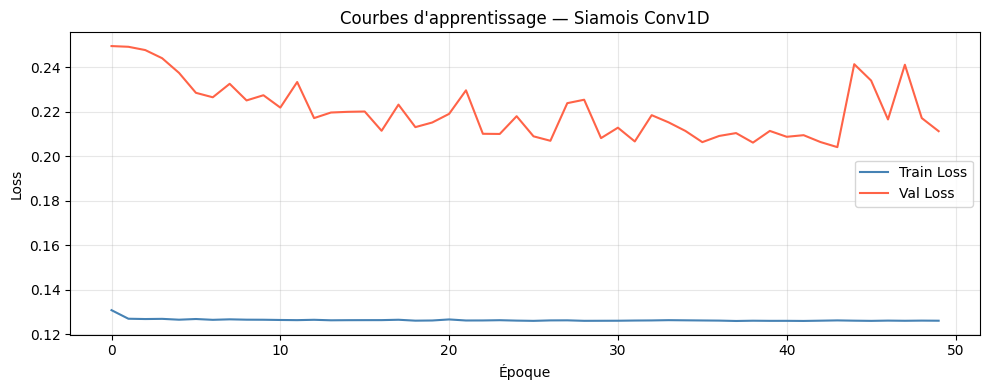

✅ Figure sauvegardée

  ÉVALUATION — Siamois Conv1D
  Seuil optimal : 0.1206
  Accuracy      : 80.44%
  F1-score      : 0.8007
  AUC           : 0.8613

                  precision    recall  f1-score   support

   Similaire (0)       0.74      0.94      0.83       225
Dissimilaire (1)       0.92      0.67      0.77       225

        accuracy                           0.80       450
       macro avg       0.83      0.80      0.80       450
    weighted avg       0.83      0.80      0.80       450



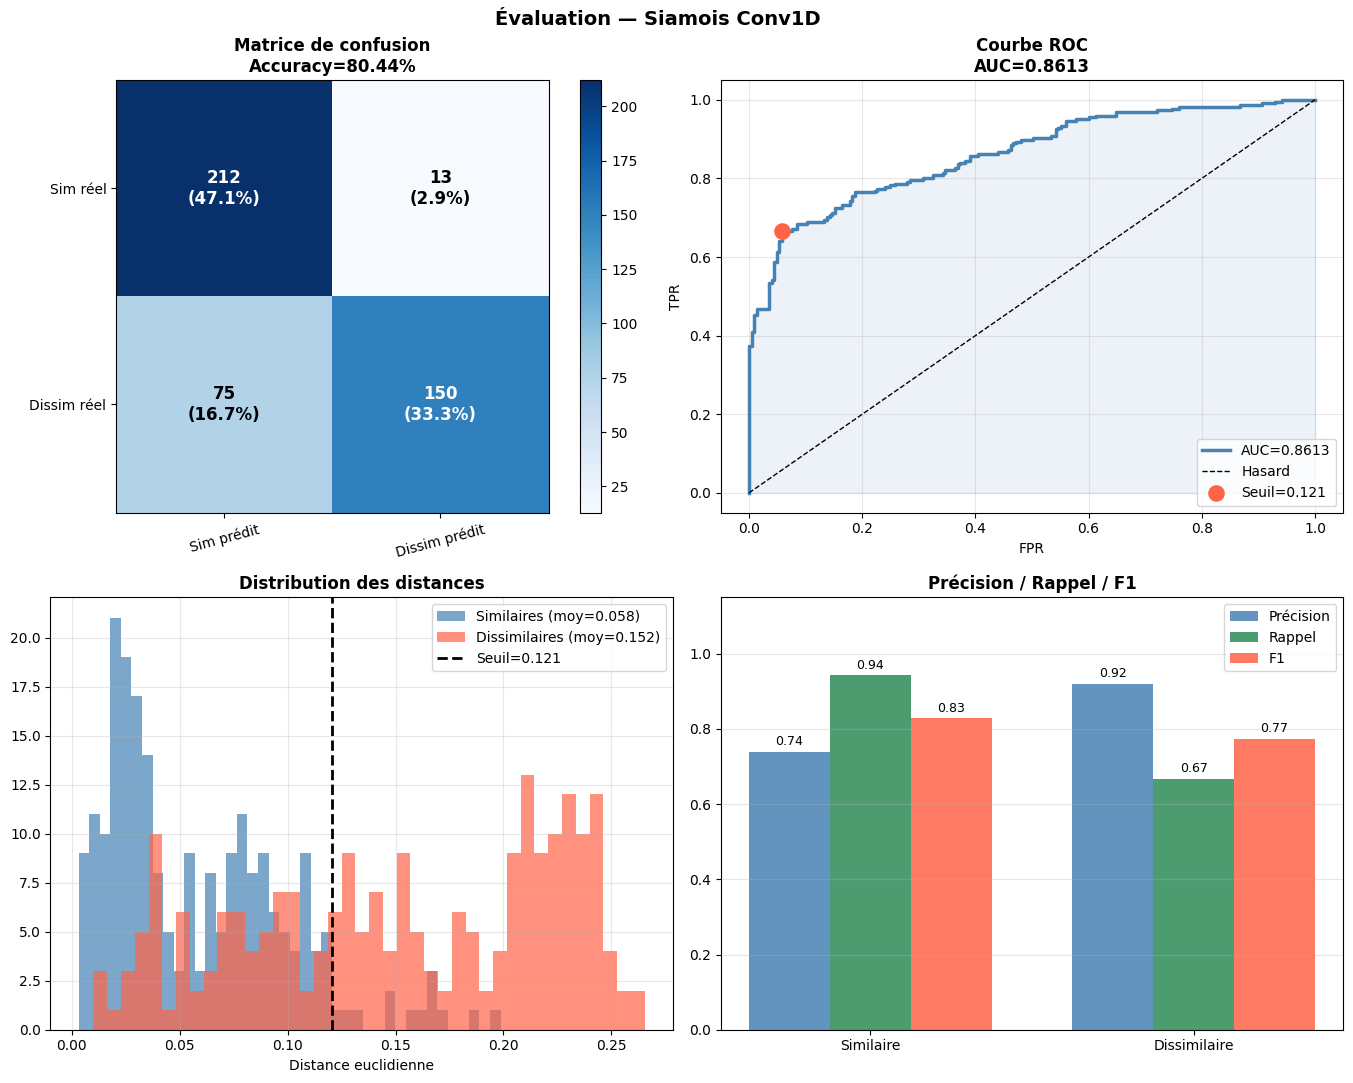

✅ Figures sauvegardées

  INTERPRÉTATION — Siamois Conv1D
  Accuracy : 0.8044  →  ✅ Bon
  F1-score : 0.8007  →  ✅ Bon
  AUC      : 0.8613  →  ✅ Bon
✅ Conv1D sauvegardé


In [27]:
history_1d = siamese_1d.fit(
    [A_tr, B_tr], y_tr,
    validation_data=([A_v, B_v], y_v),
    epochs=EPOCHS,
    batch_size=32,          # réduit car signaux plus lourds
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(DRIVE+'best_conv1d.h5', monitor='val_loss', save_best_only=True)
    ],
    verbose=1
)

plot_learning_curves(history_1d, 'Siamois Conv1D')
acc_1d, f1_1d, auc_1d = evaluate_contrastive(
    siamese_1d, A_te, B_te, y_te, 'Siamois Conv1D'
)
interpret_results(acc_1d, f1_1d, auc_1d, 'Siamois Conv1D')
siamese_1d.save(DRIVE + 'siamese_conv1d.h5')
print('✅ Conv1D sauvegardé')

---
# Partie 7.2 — Réseau Siamois Conv2D
## GASF & GADF × 224 · 512 · 1024 + Triplet Loss + Distance Cosinus

In [28]:
# ── Triplet Loss + Distance Cosinus ──────────────────────────────────────────
def triplet_loss(margin=MARGIN_T):
    def loss(y_true, y_pred):
        total   = tf.shape(y_pred)[0]
        third   = total // 3
        ancre   = y_pred[:third]
        positif = y_pred[third:2*third]
        negatif = y_pred[2*third:]
        def cosine_dist(a, b):
            a = tf.nn.l2_normalize(a, axis=1)
            b = tf.nn.l2_normalize(b, axis=1)
            return 1 - tf.reduce_sum(a * b, axis=1)
        d_pos = cosine_dist(ancre, positif)
        d_neg = cosine_dist(ancre, negatif)
        return tf.reduce_mean(tf.maximum(d_pos - d_neg + margin, 0.0))
    return loss


# ── Modèle siamois triplet ────────────────────────────────────────────────────
def build_siamese_triplet(encoder, input_shape):
    inp_a  = layers.Input(shape=input_shape, name='ancre')
    inp_p  = layers.Input(shape=input_shape, name='positif')
    inp_n  = layers.Input(shape=input_shape, name='negatif')
    emb_a  = encoder(inp_a)
    emb_p  = encoder(inp_p)
    emb_n  = encoder(inp_n)
    output = layers.Concatenate(axis=0)([emb_a, emb_p, emb_n])
    return Model([inp_a, inp_p, inp_n], output, name='siamese_triplet')


# ── Création triplets ─────────────────────────────────────────────────────────
def create_triplets(class_data, n_triplets=900, seed=SEED):
    random.seed(seed)
    classes = list(class_data.keys())
    ancres, positifs, negatifs = [], [], []
    for _ in range(n_triplets):
        cls_a = random.choice(classes)
        cls_n = random.choice([c for c in classes if c != cls_a])
        i, j  = random.sample(range(len(class_data[cls_a])), 2)
        k     = random.randint(0, len(class_data[cls_n])-1)
        ancres.append(class_data[cls_a][i])
        positifs.append(class_data[cls_a][j])
        negatifs.append(class_data[cls_n][k])
    return (
        np.array(ancres,   dtype=np.float32),
        np.array(positifs, dtype=np.float32),
        np.array(negatifs, dtype=np.float32)
    )


# ── Split triplets ────────────────────────────────────────────────────────────
def split_triplets(ancres, positifs, negatifs):
    idx = np.arange(len(ancres))
    idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
    idx_v,  idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
    return (
        ancres[idx_tr], positifs[idx_tr], negatifs[idx_tr], np.zeros(len(idx_tr)),
        ancres[idx_v],  positifs[idx_v],  negatifs[idx_v],  np.zeros(len(idx_v)),
        ancres[idx_te], positifs[idx_te], negatifs[idx_te]
    )


# ── Architecture CNN 2D ───────────────────────────────────────────────────────
def build_encoder_2d(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x); x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x); x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(4)(x); x = layers.Dropout(0.25)(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(4)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x); x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Lambda(lambda t: K.l2_normalize(t, axis=1))(x)
    return Model(inp, x, name='encoder_conv2d')


# ── Évaluation Conv2D (Triplet + Cosinus) ─────────────────────────────────────
def evaluate_triplet(encoder, A_te, P_te, N_te, model_name):
    emb_a = encoder.predict(A_te, verbose=0)
    emb_p = encoder.predict(P_te, verbose=0)
    emb_n = encoder.predict(N_te, verbose=0)

    def cosine_dist(a, b):
        a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
        b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
        return 1 - np.sum(a * b, axis=1)

    d_pos = cosine_dist(emb_a, emb_p)
    d_neg = cosine_dist(emb_a, emb_n)
    correct = (d_pos < d_neg).astype(int)
    acc     = correct.mean()

    distances_all = np.concatenate([d_pos, d_neg])
    labels_all    = np.concatenate([np.zeros(len(d_pos)), np.ones(len(d_neg))])
    fpr, tpr, thresholds = roc_curve(labels_all, distances_all)
    roc_auc   = auc(fpr, tpr)
    opt_idx   = np.argmax(tpr - fpr)
    threshold = thresholds[opt_idx]
    y_pred    = (distances_all >= threshold).astype(int)
    f1        = f1_score(labels_all, y_pred, average='weighted')

    print(f"\n{'='*52}")
    print(f'  ÉVALUATION — {model_name}')
    print(f"{'='*52}")
    print(f'  Seuil optimal            : {threshold:.4f}')
    print(f'  Accuracy (d_pos < d_neg) : {acc*100:.2f}%')
    print(f'  F1-score                 : {f1:.4f}')
    print(f'  AUC                      : {roc_auc:.4f}')
    print(f"{'='*52}")
    print(f'  d_pos : {d_pos.mean():.4f} ± {d_pos.std():.4f}')
    print(f'  d_neg : {d_neg.mean():.4f} ± {d_neg.std():.4f}')
    print(f'  Séparation : {(d_neg-d_pos).mean():.4f}')
    print(f'  Corrects   : {correct.sum()}/{len(correct)}')
    print()
    print(classification_report(labels_all, y_pred,
          target_names=['Positif (sim)', 'Négatif (dissim)']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    cm = confusion_matrix(labels_all, y_pred)
    im = axes[0,0].imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=axes[0,0])
    for i in range(2):
        for j in range(2):
            axes[0,0].text(j, i, f"{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)",
                           ha='center', va='center', fontsize=12, fontweight='bold',
                           color='white' if cm[i,j]>cm.max()/2 else 'black')
    axes[0,0].set_xticks([0,1]); axes[0,0].set_xticklabels(['Pos prédit','Neg prédit'], rotation=15)
    axes[0,0].set_yticks([0,1]); axes[0,0].set_yticklabels(['Pos réel','Neg réel'])
    axes[0,0].set_title(f'Matrice de confusion\nAccuracy={acc*100:.2f}%', fontweight='bold')

    axes[0,1].plot(fpr, tpr, color='steelblue', lw=2.5, label=f'AUC={roc_auc:.4f}')
    axes[0,1].plot([0,1],[0,1],'k--',lw=1, label='Hasard')
    axes[0,1].scatter(fpr[opt_idx], tpr[opt_idx], color='tomato', s=120, zorder=5,
                      label=f'Seuil={threshold:.3f}')
    axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
    axes[0,1].set_title(f'Courbe ROC\nAUC={roc_auc:.4f}', fontweight='bold')
    axes[0,1].legend(loc='lower right'); axes[0,1].grid(True, alpha=0.3)

    axes[1,0].hist(d_pos, bins=40, alpha=0.7, color='steelblue',
                   label=f'Ancre-Positif (moy={d_pos.mean():.3f})')
    axes[1,0].hist(d_neg, bins=40, alpha=0.7, color='tomato',
                   label=f'Ancre-Negatif (moy={d_neg.mean():.3f})')
    axes[1,0].axvline(threshold, color='black', linestyle='--', lw=2,
                      label=f'Seuil={threshold:.3f}')
    axes[1,0].set_xlabel('Distance cosinus')
    axes[1,0].set_title('Distribution des distances cosinus', fontweight='bold')
    axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

    prec, rec, f1s, _ = precision_recall_fscore_support(labels_all, y_pred, labels=[0,1])
    x = np.arange(2); w = 0.25
    b1 = axes[1,1].bar(x-w, prec, width=w, label='Précision', color='steelblue', alpha=0.85)
    b2 = axes[1,1].bar(x,   rec,  width=w, label='Rappel',    color='seagreen',  alpha=0.85)
    b3 = axes[1,1].bar(x+w, f1s,  width=w, label='F1',        color='tomato',    alpha=0.85)
    for bars in [b1,b2,b3]:
        for bar in bars:
            h = bar.get_height()
            axes[1,1].text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=9)
    axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(['Positif\n(sim)','Negatif\n(dissim)'])
    axes[1,1].set_ylim(0,1.15)
    axes[1,1].set_title('Précision / Rappel / F1', fontweight='bold')
    axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Évaluation complète — {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = model_name.lower().replace(' ','_').replace('/','_').replace('×','x')
    plt.savefig(DRIVE + f'{fname}_evaluation.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✅ Figures sauvegardées')
    return acc, f1, roc_auc


# Batch size selon taille
BATCH_CONFIG   = {224: 8, 512: 4, 1024: 4}
TRIPLET_CONFIG = {224: 900, 512: 600, 1024: 300}

# Stockage résultats
all_results = {}

print('Fonctions Conv2D OK ✅')

Fonctions Conv2D OK ✅


---
## Boucle d'entraînement Conv2D
### GASF 224 → GADF 224 → GASF 512 → GADF 512 → GASF 1024 → GADF 1024

> La VRAM est libérée entre chaque modèle pour éviter les crashes RAM.


  Conv2D GASF 224x224
Shape : (100, 224, 224, 1)
Train:630 | Val:135 | Test:135
Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - loss: 0.2978

79/79 ━━━━━━━━━━━━━━━━━━━━ 69s 477ms/step - loss: 0.2979 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.2924 - val_loss: 0.3187 - learning_rate: 0.0010
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.2897

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - loss: 0.2832 - val_loss: 0.2969 - learning_rate: 0.0010
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.2903

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 0.2806 - val_loss: 0.2954 - learning_rate: 0.0010
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.2630

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - loss: 0.2655 - val_loss: 0.2575 - learning_rate: 0.0010
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.2562 - val_loss: 0.2763 - learning_rate: 0.0010
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.2448 - val_loss: 0.2621 - learning_rate: 0.0010
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.2432 - val_loss: 0.2876 - learning_rate: 0.0010
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.2320

...

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 0.1864 - val_loss: 0.2238 - learning_rate: 0.0010
Epoch 23/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1708

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - loss: 0.1807 - val_loss: 0.2102 - learning_rate: 0.0010
Epoch 24/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.1650

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.1688 - val_loss: 0.1967 - learning_rate: 0.0010
Epoch 25/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1672 - val_loss: 0.2263 - learning_rate: 0.0010
Epoch 26/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1521 - val_loss: 0.2351 - learning_rate: 0.0010
Epoch 27/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1555 - val_loss: 0.2302 - learning_rate: 0.0010
Epoch 28/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1387 - val_loss: 0.2005 - learning_rate: 0.0010
Epoch 29/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1301 - val_loss: 0.2431 - learning_rate: 0.0010
Epoch 30/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1228 - val_loss: 0.2056 - learning_rate: 5.0000e-04
Epoch 31/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1111 - val_loss: 0.2045 - learning_rate: 5.0000e-04
Epoch 32/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0986

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 0.1046 - val_loss: 0.1484 - learning_rate: 5.0000e-04
Epoch 33/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1013 - val_loss: 0.1761 - learning_rate: 5.0000e-04
Epoch 34/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0937 - val_loss: 0.1976 - learning_rate: 5.0000e-04
Epoch 35/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0797 - val_loss: 0.1627 - learning_rate: 5.0000e-04
Epoch 36/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0941 - val_loss: 0.1669 - learning_rate: 5.0000e-04
Epoch 37/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0797 - val_loss: 0.1558 - learning_rate: 5.0000e-04
Epoch 38/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0739

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.0776 - val_loss: 0.1220 - learning_rate: 2.5000e-04
Epoch 39/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0675 - val_loss: 0.1498 - learning_rate: 2.5000e-04
Epoch 40/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - loss: 0.0685 - val_loss: 0.1356 - learning_rate: 2.5000e-04
Epoch 41/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0685 - val_loss: 0.1498 - learning_rate: 2.5000e-04
Epoch 42/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.0695 - val_loss: 0.1507 - learning_rate: 2.5000e-04
Epoch 43/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0599 - val_loss: 0.1445 - learning_rate: 2.5000e-04
Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0638 - val_loss: 0.1432 - learning_rate: 1.2500e-04
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0552 - val_loss: 0.1311 - learning_rate: 1.2500e-04
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0542 - val_loss: 0.1279 - l

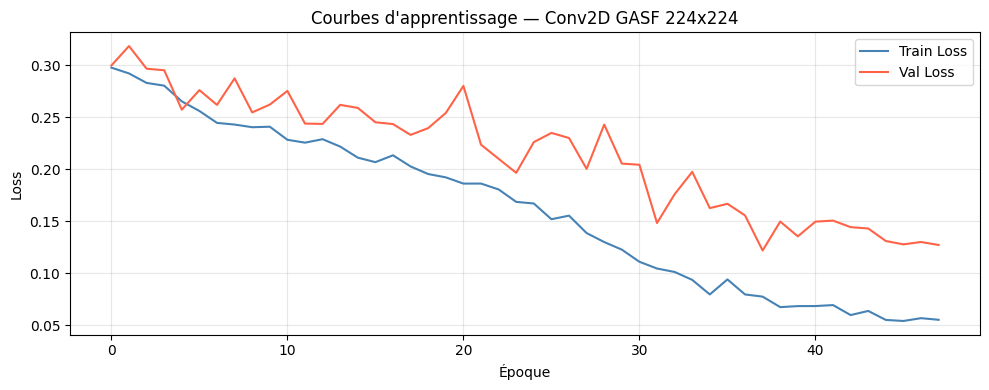

✅ Figure sauvegardée

  ÉVALUATION — Conv2D GASF 224x224
  Seuil optimal            : 0.2281
  Accuracy (d_pos < d_neg) : 80.00%
  F1-score                 : 0.7814
  AUC                      : 0.8139
  d_pos : 0.1780 ± 0.2550
  d_neg : 0.5909 ± 0.3425
  Séparation : 0.4130
  Corrects   : 108/135

                  precision    recall  f1-score   support

   Positif (sim)       0.79      0.76      0.78       135
Négatif (dissim)       0.77      0.80      0.79       135

        accuracy                           0.78       270
       macro avg       0.78      0.78      0.78       270
    weighted avg       0.78      0.78      0.78       270



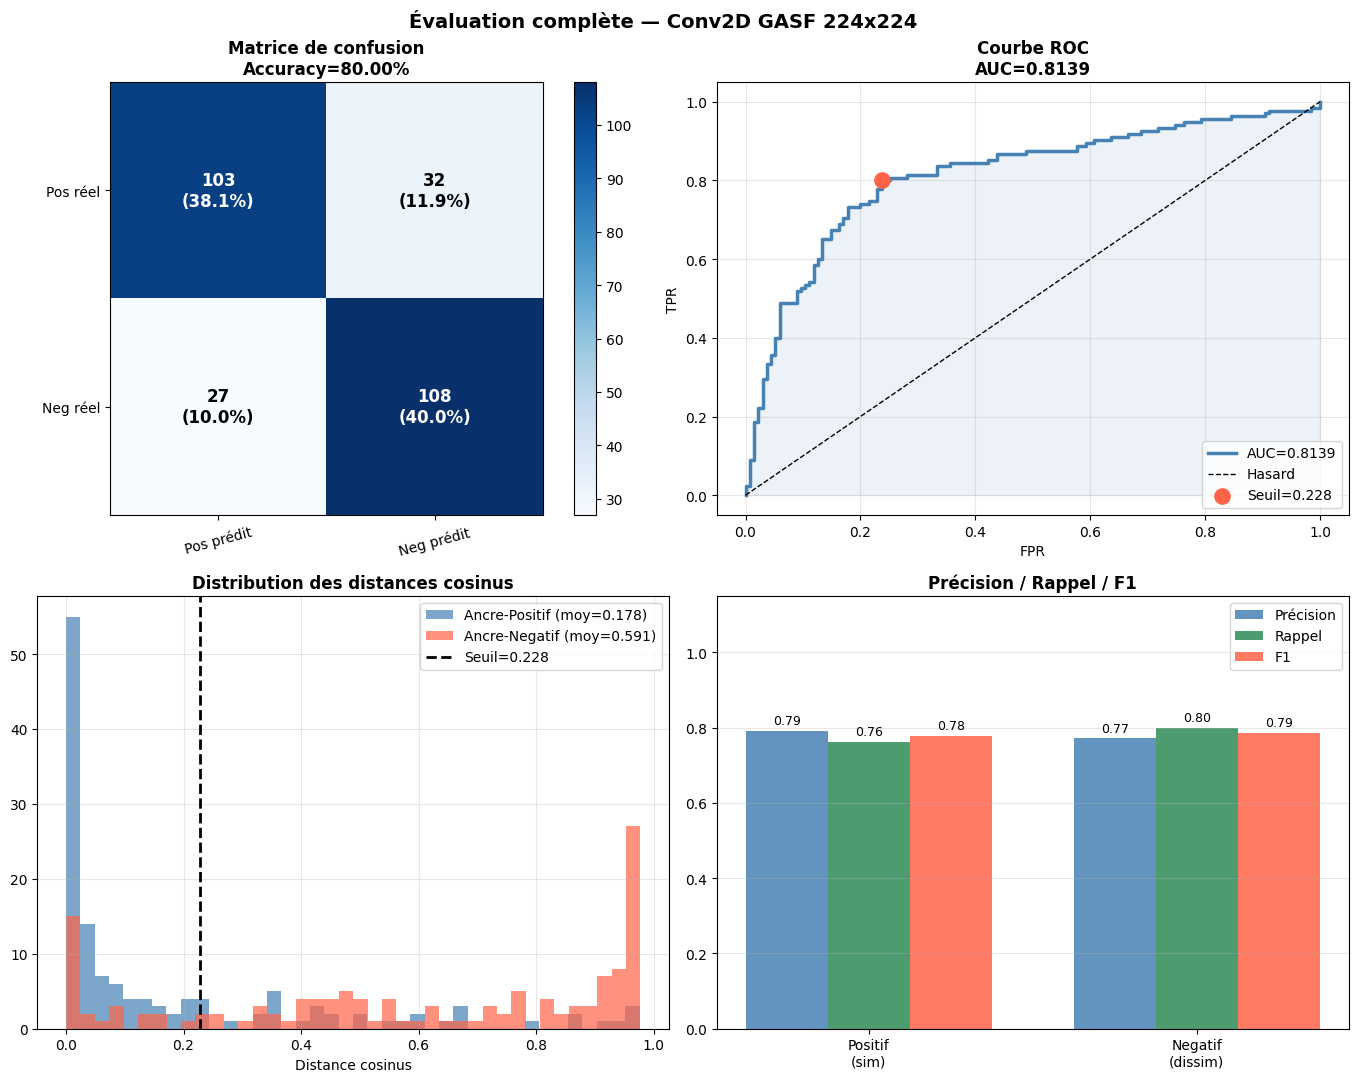

✅ Figures sauvegardées

  INTERPRÉTATION — Conv2D GASF 224x224
  Accuracy : 0.8000  →  ✅ Bon
  F1-score : 0.7814  →  ⚠️  Acceptable
  AUC      : 0.8139  →  ✅ Bon
✅ Terminé — Mémoire libérée


In [29]:
# ════════════════════════════════════════════════
# Modèle 1 — GASF 224×224
# ════════════════════════════════════════════════
METHOD, SIZE = 'GASF', 224
IMG_SHAPE    = (SIZE, SIZE, 1)
MODEL_NAME   = f'Conv2D {METHOD} {SIZE}x{SIZE}'
print(f'\n{"="*50}\n  {MODEL_NAME}\n{"="*50}')

imgs = {
    0: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/normal', SIZE),
    1: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/irf',    SIZE),
    2: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/orf',    SIZE)
}
print(f'Shape : {imgs[0].shape}')

ancres, positifs, negatifs = create_triplets(imgs, n_triplets=TRIPLET_CONFIG[SIZE])
idx = np.arange(len(ancres))
idx_tr,idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_v, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
A_tr=ancres[idx_tr]; P_tr=positifs[idx_tr]; N_tr=negatifs[idx_tr]; y_tr=np.zeros(len(idx_tr))
A_v =ancres[idx_v];  P_v =positifs[idx_v];  N_v =negatifs[idx_v];  y_v =np.zeros(len(idx_v))
A_te=ancres[idx_te]; P_te=positifs[idx_te]; N_te=negatifs[idx_te]
print(f'Train:{len(y_tr)} | Val:{len(y_v)} | Test:{len(A_te)}')

enc  = build_encoder_2d(IMG_SHAPE)
siam = build_siamese_triplet(enc, IMG_SHAPE)
siam.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=triplet_loss(MARGIN_T))

hist = siam.fit(
    [A_tr,P_tr,N_tr], y_tr,
    validation_data=([A_v,P_v,N_v], y_v),
    epochs=EPOCHS, batch_size=BATCH_CONFIG[SIZE],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(DRIVE+f'best_{METHOD}_{SIZE}.h5', monitor='val_loss', save_best_only=True)
    ], verbose=1
)

plot_learning_curves(hist, MODEL_NAME)
acc,f1,roc_auc = evaluate_triplet(enc, A_te, P_te, N_te, MODEL_NAME)
interpret_results(acc, f1, roc_auc, MODEL_NAME)
all_results[f'{METHOD}_{SIZE}'] = {'acc':acc,'f1':f1,'auc':roc_auc}
enc.save(DRIVE + f'encoder_{METHOD}_{SIZE}.h5')

del imgs,ancres,positifs,negatifs,A_tr,P_tr,N_tr,A_v,P_v,N_v,A_te,P_te,N_te,enc,siam,hist
gc.collect(); tf.keras.backend.clear_session()
print('✅ Terminé — Mémoire libérée')


  Conv2D GADF 224x224
Shape : (100, 224, 224, 1)
Train:630 | Val:135 | Test:135
Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - loss: 0.2956

79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 409ms/step - loss: 0.2960 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.2982

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - loss: 0.2992 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.2938

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - loss: 0.2943 - val_loss: 0.2976 - learning_rate: 0.0010
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.2970 - val_loss: 0.3002 - learning_rate: 0.0010
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.2939 - val_loss: 0.2999 - learning_rate: 0.0010
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.2852 - val_loss: 0.3010 - learning_rate: 0.0010
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.2604

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.2661 - val_loss: 0.2849 - learning_rate: 0.0010
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.2662 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.2541

...

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 142ms/step - loss: 0.1965 - val_loss: 0.2077 - learning_rate: 5.0000e-04
Epoch 23/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1910 - val_loss: 0.2930 - learning_rate: 5.0000e-04
Epoch 24/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.1833 - val_loss: 0.2790 - learning_rate: 5.0000e-04
Epoch 25/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1861 - val_loss: 0.3058 - learning_rate: 5.0000e-04
Epoch 26/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1830 - val_loss: 0.2599 - learning_rate: 5.0000e-04
Epoch 27/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1662 - val_loss: 0.3137 - learning_rate: 5.0000e-04
Epoch 28/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.1698 - val_loss: 0.2956 - learning_rate: 2.5000e-04
Epoch 29/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1598 - val_loss: 0.2370 - learning_rate: 2.5000e-04
Epoch 30/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1550

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.1560 - val_loss: 0.2041 - learning_rate: 2.5000e-04
Epoch 31/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1593 - val_loss: 0.2149 - learning_rate: 2.5000e-04
Epoch 32/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1593 - val_loss: 0.2431 - learning_rate: 2.5000e-04
Epoch 33/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1523 - val_loss: 0.2451 - learning_rate: 2.5000e-04
Epoch 34/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1546 - val_loss: 0.2226 - learning_rate: 2.5000e-04
Epoch 35/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1487

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.1522 - val_loss: 0.1967 - learning_rate: 2.5000e-04
Epoch 36/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1532 - val_loss: 0.2025 - learning_rate: 2.5000e-04
Epoch 37/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1504 - val_loss: 0.1981 - learning_rate: 2.5000e-04
Epoch 38/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.1462

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.1445 - val_loss: 0.1872 - learning_rate: 2.5000e-04
Epoch 39/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1537 - val_loss: 0.3050 - learning_rate: 2.5000e-04
Epoch 40/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1498 - val_loss: 0.2364 - learning_rate: 2.5000e-04
Epoch 41/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1398 - val_loss: 0.1942 - learning_rate: 2.5000e-04
Epoch 42/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1399 - val_loss: 0.2331 - learning_rate: 2.5000e-04
Epoch 43/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1478 - val_loss: 0.2721 - learning_rate: 2.5000e-04
Epoch 44/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1299 - val_loss: 0.2001 - learning_rate: 1.2500e-04
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1377 - val_loss: 0.2095 - learning_rate: 1.2500e-04
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1357 - val_loss: 0.2050 - le

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.1386 - val_loss: 0.1865 - learning_rate: 1.2500e-04
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1301 - val_loss: 0.2083 - learning_rate: 1.2500e-04
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.1338 - val_loss: 0.1929 - learning_rate: 1.2500e-04
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.1327 - val_loss: 0.2246 - learning_rate: 1.2500e-04


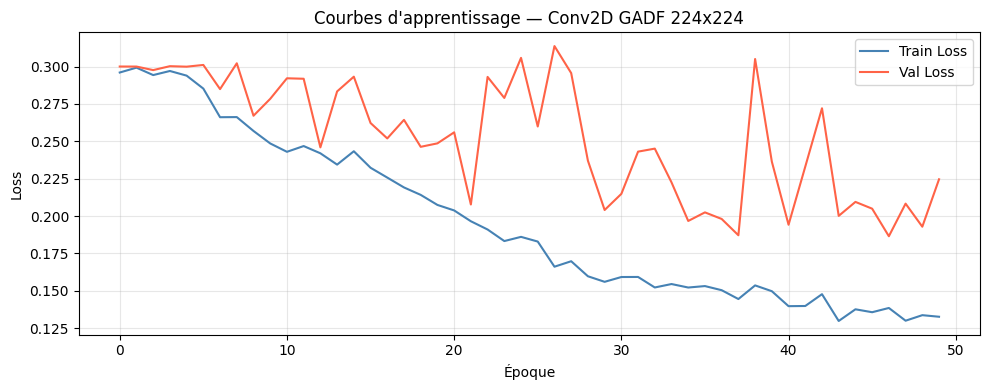

✅ Figure sauvegardée

  ÉVALUATION — Conv2D GADF 224x224
  Seuil optimal            : 0.1595
  Accuracy (d_pos < d_neg) : 67.41%
  F1-score                 : 0.6881
  AUC                      : 0.7063
  d_pos : 0.1079 ± 0.1675
  d_neg : 0.2558 ± 0.1910
  Séparation : 0.1479
  Corrects   : 91/135

                  precision    recall  f1-score   support

   Positif (sim)       0.67      0.74      0.70       135
Négatif (dissim)       0.71      0.64      0.67       135

        accuracy                           0.69       270
       macro avg       0.69      0.69      0.69       270
    weighted avg       0.69      0.69      0.69       270



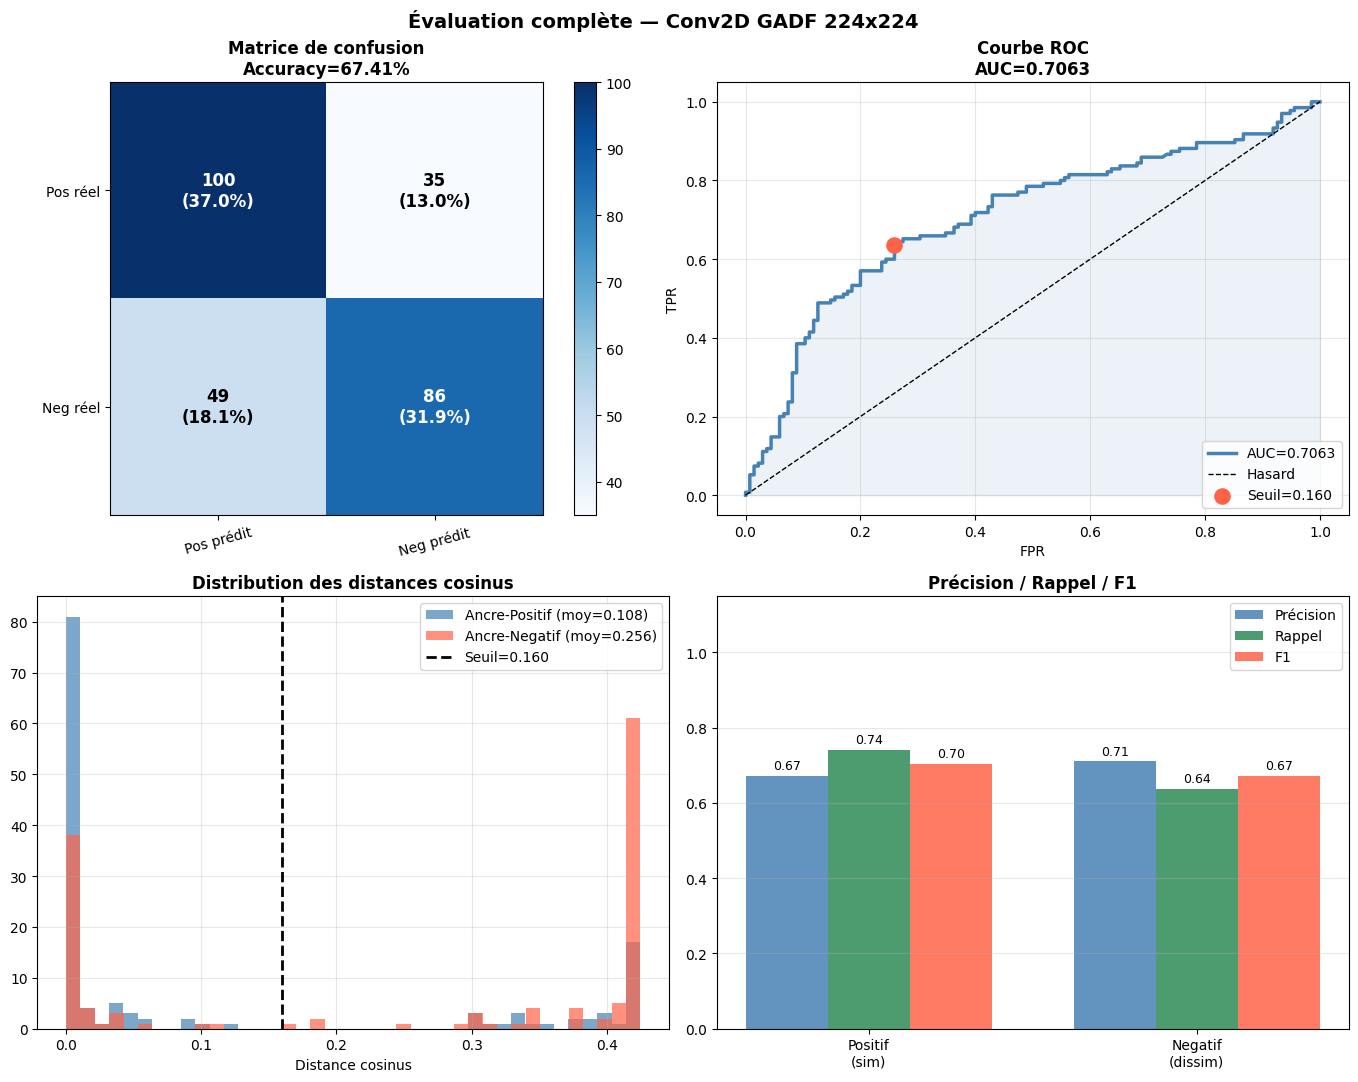

✅ Figures sauvegardées

  INTERPRÉTATION — Conv2D GADF 224x224
  Accuracy : 0.6741  →  ❌ Insuffisant
  F1-score : 0.6881  →  ❌ Insuffisant
  AUC      : 0.7063  →  ⚠️  Acceptable
✅ Terminé — Mémoire libérée


In [30]:
# ════════════════════════════════════════════════
# Modèle 2 — GADF 224×224
# ════════════════════════════════════════════════
METHOD, SIZE = 'GADF', 224
IMG_SHAPE    = (SIZE, SIZE, 1)
MODEL_NAME   = f'Conv2D {METHOD} {SIZE}x{SIZE}'
print(f'\n{"="*50}\n  {MODEL_NAME}\n{"="*50}')

imgs = {
    0: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/normal', SIZE),
    1: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/irf',    SIZE),
    2: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/orf',    SIZE)
}
print(f'Shape : {imgs[0].shape}')

ancres, positifs, negatifs = create_triplets(imgs, n_triplets=TRIPLET_CONFIG[SIZE])
idx = np.arange(len(ancres))
idx_tr,idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_v, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
A_tr=ancres[idx_tr]; P_tr=positifs[idx_tr]; N_tr=negatifs[idx_tr]; y_tr=np.zeros(len(idx_tr))
A_v =ancres[idx_v];  P_v =positifs[idx_v];  N_v =negatifs[idx_v];  y_v =np.zeros(len(idx_v))
A_te=ancres[idx_te]; P_te=positifs[idx_te]; N_te=negatifs[idx_te]
print(f'Train:{len(y_tr)} | Val:{len(y_v)} | Test:{len(A_te)}')

enc  = build_encoder_2d(IMG_SHAPE)
siam = build_siamese_triplet(enc, IMG_SHAPE)
siam.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=triplet_loss(MARGIN_T))

hist = siam.fit(
    [A_tr,P_tr,N_tr], y_tr,
    validation_data=([A_v,P_v,N_v], y_v),
    epochs=EPOCHS, batch_size=BATCH_CONFIG[SIZE],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(DRIVE+f'best_{METHOD}_{SIZE}.h5', monitor='val_loss', save_best_only=True)
    ], verbose=1
)

plot_learning_curves(hist, MODEL_NAME)
acc,f1,roc_auc = evaluate_triplet(enc, A_te, P_te, N_te, MODEL_NAME)
interpret_results(acc, f1, roc_auc, MODEL_NAME)
all_results[f'{METHOD}_{SIZE}'] = {'acc':acc,'f1':f1,'auc':roc_auc}
enc.save(DRIVE + f'encoder_{METHOD}_{SIZE}.h5')

del imgs,ancres,positifs,negatifs,A_tr,P_tr,N_tr,A_v,P_v,N_v,A_te,P_te,N_te,enc,siam,hist
gc.collect(); tf.keras.backend.clear_session()
print('✅ Terminé — Mémoire libérée')


  Conv2D GASF 512x512
Shape : (100, 512, 512, 1)
Train:420 | Val:90 | Test:90
Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - loss: 0.2998

105/105 ━━━━━━━━━━━━━━━━━━━━ 71s 346ms/step - loss: 0.3009 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.3055

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 286ms/step - loss: 0.3033 - val_loss: 0.2993 - learning_rate: 0.0010
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - loss: 0.2961

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 289ms/step - loss: 0.2954 - val_loss: 0.2969 - learning_rate: 0.0010
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - loss: 0.3004 - val_loss: 0.2986 - learning_rate: 0.0010
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2981 - val_loss: 0.3001 - learning_rate: 0.0010
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2990 - val_loss: 0.2999 - learning_rate: 0.0010
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.3060 - val_loss: 0.2996 - learning_rate: 0.0010
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 281ms/step - loss: 0.2894 - val_loss: 0.2970 - learning_rate: 0.0010
Epoch 9/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 0.2869

105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 291ms/step - loss: 0.2871 - val_loss: 0.2932 - learning_rate: 5.0000e-04
Epoch 10/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2935 - val_loss: 0.3029 - learning_rate: 5.0000e-04
Epoch 11/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 281ms/step - loss: 0.2999 - val_loss: 0.2995 - learning_rate: 5.0000e-04
Epoch 12/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2859 - val_loss: 0.3053 - learning_rate: 5.0000e-04
Epoch 13/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 41s 284ms/step - loss: 0.2876 - val_loss: 0.3143 - learning_rate: 5.0000e-04
Epoch 14/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - loss: 0.2895

105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 292ms/step - loss: 0.2904 - val_loss: 0.2908 - learning_rate: 5.0000e-04
Epoch 15/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.2892

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 288ms/step - loss: 0.2921 - val_loss: 0.2865 - learning_rate: 5.0000e-04
Epoch 16/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 281ms/step - loss: 0.2617 - val_loss: 0.2929 - learning_rate: 5.0000e-04
Epoch 17/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2793 - val_loss: 0.2878 - learning_rate: 5.0000e-04
Epoch 18/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2607 - val_loss: 0.3018 - learning_rate: 5.0000e-04
Epoch 19/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2500 - val_loss: 0.3080 - learning_rate: 5.0000e-04
Epoch 20/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2594 - val_loss: 0.2999 - learning_rate: 5.0000e-04
Epoch 21/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2493 - val_loss: 0.2996 - learning_rate: 2.5000e-04
Epoch 22/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - loss: 0.2447 - val_loss: 0.3058 - learning_rate: 2.5000e-04
Epoch 23/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - loss: 0.23

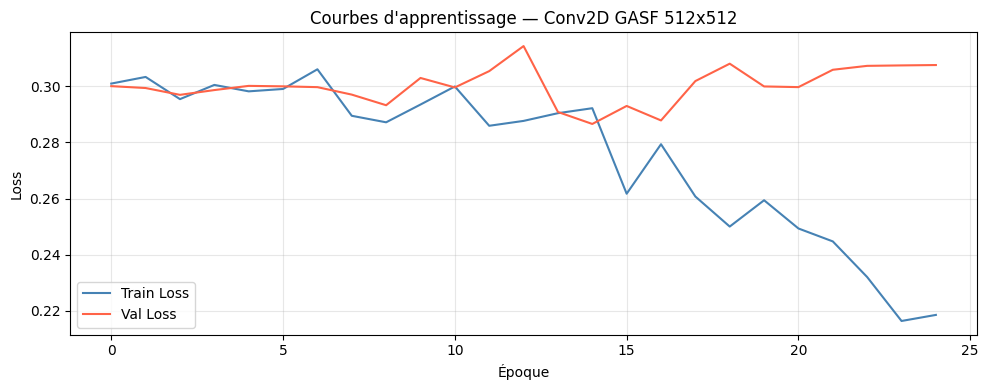

✅ Figure sauvegardée

  ÉVALUATION — Conv2D GASF 512x512
  Seuil optimal            : 0.0780
  Accuracy (d_pos < d_neg) : 51.11%
  F1-score                 : 0.5319
  AUC                      : 0.4919
  d_pos : 0.1286 ± 0.1662
  d_neg : 0.1184 ± 0.1494
  Séparation : -0.0102
  Corrects   : 46/90

                  precision    recall  f1-score   support

   Positif (sim)       0.53      0.59      0.56        90
Négatif (dissim)       0.54      0.48      0.51        90

        accuracy                           0.53       180
       macro avg       0.53      0.53      0.53       180
    weighted avg       0.53      0.53      0.53       180



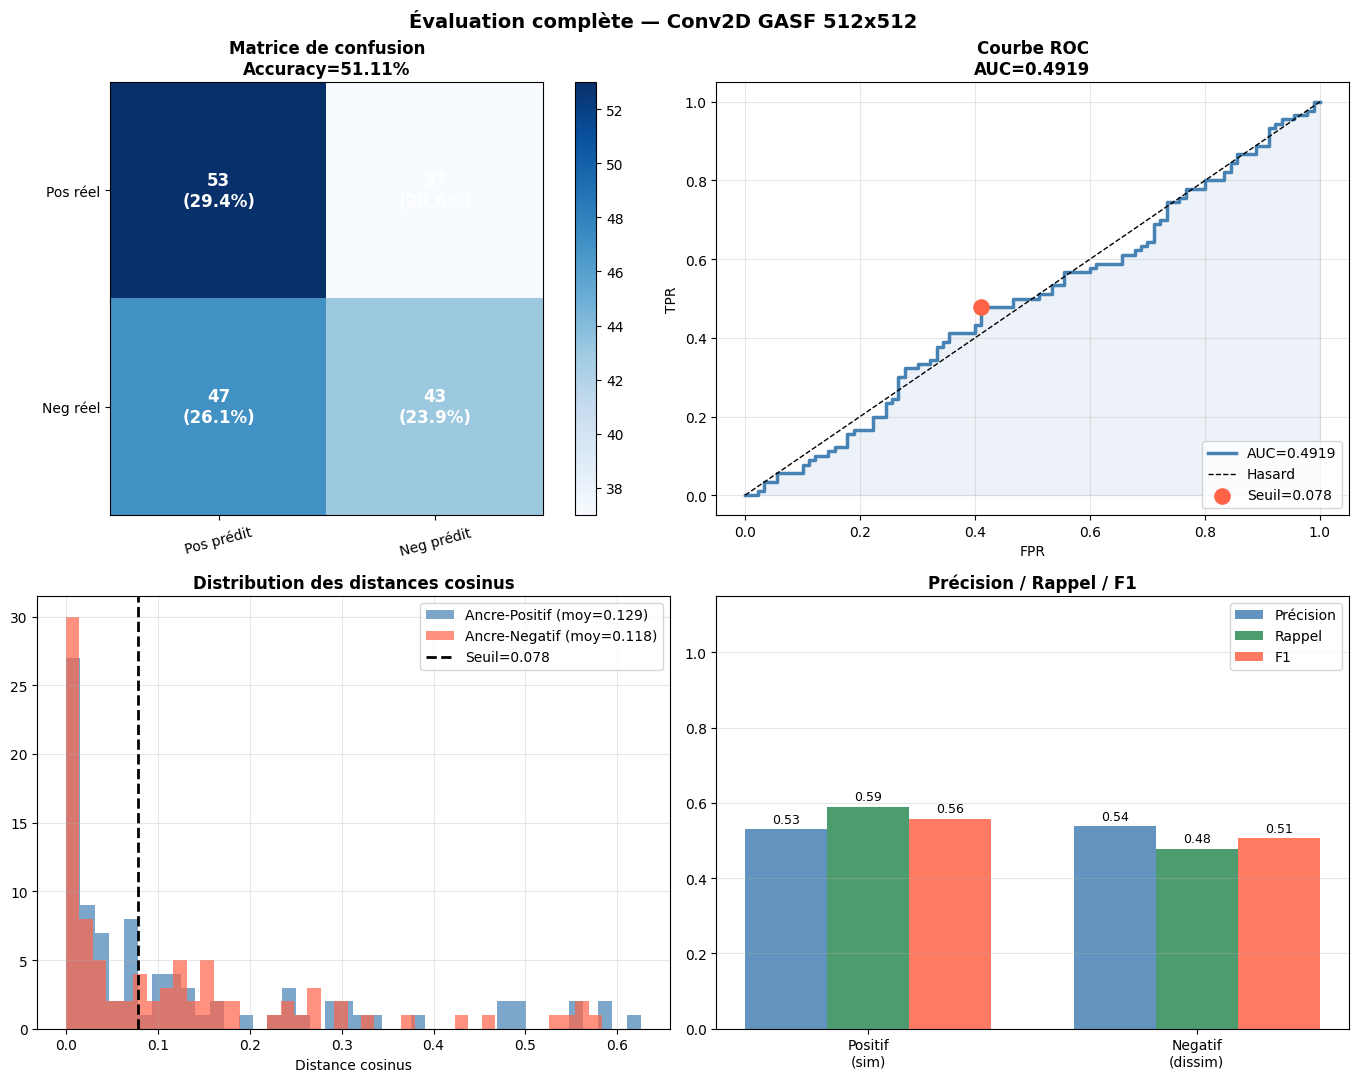

✅ Figures sauvegardées

  INTERPRÉTATION — Conv2D GASF 512x512
  Accuracy : 0.5111  →  ❌ Insuffisant
  F1-score : 0.5319  →  ❌ Insuffisant
  AUC      : 0.4919  →  ❌ Insuffisant
  ⚠️  → Vérifier que les images sont bien générées avec PAA
✅ Terminé — Mémoire libérée


In [31]:
# ════════════════════════════════════════════════
# Modèle 3 — GASF 512×512
# ════════════════════════════════════════════════
METHOD, SIZE = 'GASF', 512
IMG_SHAPE    = (SIZE, SIZE, 1)
MODEL_NAME   = f'Conv2D {METHOD} {SIZE}x{SIZE}'
print(f'\n{"="*50}\n  {MODEL_NAME}\n{"="*50}')

imgs = {
    0: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/normal', SIZE),
    1: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/irf',    SIZE),
    2: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/orf',    SIZE)
}
print(f'Shape : {imgs[0].shape}')

ancres, positifs, negatifs = create_triplets(imgs, n_triplets=TRIPLET_CONFIG[SIZE])
idx = np.arange(len(ancres))
idx_tr,idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_v, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
A_tr=ancres[idx_tr]; P_tr=positifs[idx_tr]; N_tr=negatifs[idx_tr]; y_tr=np.zeros(len(idx_tr))
A_v =ancres[idx_v];  P_v =positifs[idx_v];  N_v =negatifs[idx_v];  y_v =np.zeros(len(idx_v))
A_te=ancres[idx_te]; P_te=positifs[idx_te]; N_te=negatifs[idx_te]
print(f'Train:{len(y_tr)} | Val:{len(y_v)} | Test:{len(A_te)}')

enc  = build_encoder_2d(IMG_SHAPE)
siam = build_siamese_triplet(enc, IMG_SHAPE)
siam.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=triplet_loss(MARGIN_T))

hist = siam.fit(
    [A_tr,P_tr,N_tr], y_tr,
    validation_data=([A_v,P_v,N_v], y_v),
    epochs=EPOCHS, batch_size=BATCH_CONFIG[SIZE],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(DRIVE+f'best_{METHOD}_{SIZE}.h5', monitor='val_loss', save_best_only=True)
    ], verbose=1
)

plot_learning_curves(hist, MODEL_NAME)
acc,f1,roc_auc = evaluate_triplet(enc, A_te, P_te, N_te, MODEL_NAME)
interpret_results(acc, f1, roc_auc, MODEL_NAME)
all_results[f'{METHOD}_{SIZE}'] = {'acc':acc,'f1':f1,'auc':roc_auc}
enc.save(DRIVE + f'encoder_{METHOD}_{SIZE}.h5')

del imgs,ancres,positifs,negatifs,A_tr,P_tr,N_tr,A_v,P_v,N_v,A_te,P_te,N_te,enc,siam,hist
gc.collect(); tf.keras.backend.clear_session()
print('✅ Terminé — Mémoire libérée')


  Conv2D GADF 512x512
Shape : (100, 512, 512, 1)
Train:420 | Val:90 | Test:90
Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 0.2962

105/105 ━━━━━━━━━━━━━━━━━━━━ 60s 333ms/step - loss: 0.2979 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 0.3099

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 290ms/step - loss: 0.3047 - val_loss: 0.2998 - learning_rate: 0.0010
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.2972

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 287ms/step - loss: 0.2960 - val_loss: 0.2985 - learning_rate: 0.0010
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 293ms/step - loss: 0.3036 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2966 - val_loss: 0.3001 - learning_rate: 0.0010
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.2973

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 288ms/step - loss: 0.2964 - val_loss: 0.2947 - learning_rate: 0.0010
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2972 - val_loss: 0.2977 - learning_rate: 0.0010
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2994 - val_loss: 0.3000 - learning_rate: 0.0010
Epoch 9/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.3048 - val_loss: 0.2996 - learning_rate: 0.0010
Epoch 10/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.3009 - val_loss: 0.2971 - learning_rate: 0.0010
Epoch 11/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 42s 284ms/step - loss: 0.2980 - val_loss: 0.3001 - learning_rate: 0.0010
Epoch 12/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 283ms/step - loss: 0.3028 - val_loss: 0.2967 - learning_rate: 5.0000e-04
Epoch 13/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 278ms/step - loss: 0.2943 - val_loss: 0.2972 - learning_rate: 5.0000e-04
Epoch 14/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2935 - val_loss: 0.2949 - lea

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 288ms/step - loss: 0.2916 - val_loss: 0.2938 - learning_rate: 5.0000e-04
Epoch 16/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 278ms/step - loss: 0.2888 - val_loss: 0.3006 - learning_rate: 5.0000e-04
Epoch 17/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2922 - val_loss: 0.2952 - learning_rate: 5.0000e-04
Epoch 18/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2886 - val_loss: 0.2967 - learning_rate: 5.0000e-04
Epoch 19/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2910 - val_loss: 0.3002 - learning_rate: 5.0000e-04
Epoch 20/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.2854

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 289ms/step - loss: 0.2915 - val_loss: 0.2914 - learning_rate: 5.0000e-04
Epoch 21/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2939 - val_loss: 0.2934 - learning_rate: 5.0000e-04
Epoch 22/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 278ms/step - loss: 0.2921 - val_loss: 0.3004 - learning_rate: 5.0000e-04
Epoch 23/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 278ms/step - loss: 0.2965 - val_loss: 0.2929 - learning_rate: 5.0000e-04
Epoch 24/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2950 - val_loss: 0.2927 - learning_rate: 5.0000e-04
Epoch 25/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2888 - val_loss: 0.2948 - learning_rate: 5.0000e-04
Epoch 26/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2918 - val_loss: 0.2975 - learning_rate: 2.5000e-04
Epoch 27/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.2831

105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 288ms/step - loss: 0.2837 - val_loss: 0.2871 - learning_rate: 2.5000e-04
Epoch 28/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 278ms/step - loss: 0.2739 - val_loss: 0.2926 - learning_rate: 2.5000e-04
Epoch 29/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2768 - val_loss: 0.2924 - learning_rate: 2.5000e-04
Epoch 30/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2683 - val_loss: 0.2926 - learning_rate: 2.5000e-04
Epoch 31/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2688 - val_loss: 0.2996 - learning_rate: 2.5000e-04
Epoch 32/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2555 - val_loss: 0.3147 - learning_rate: 2.5000e-04
Epoch 33/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 279ms/step - loss: 0.2483 - val_loss: 0.3426 - learning_rate: 1.2500e-04
Epoch 34/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.2448 - val_loss: 0.3474 - learning_rate: 1.2500e-04
Epoch 35/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 280ms/step - loss: 0.23

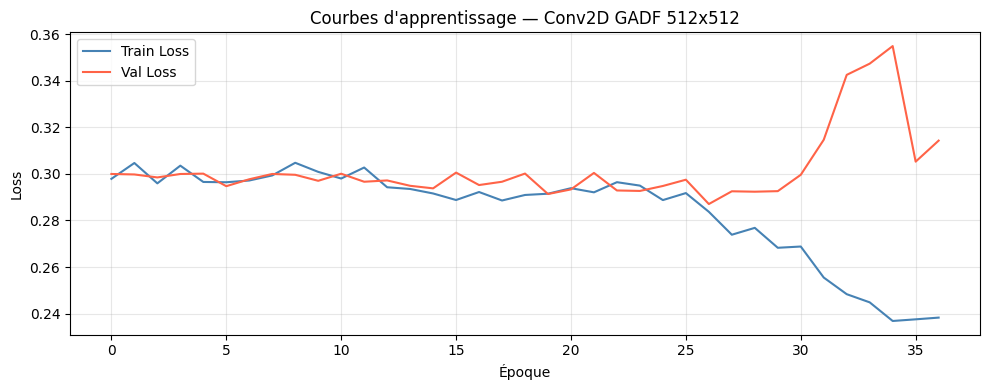

✅ Figure sauvegardée

  ÉVALUATION — Conv2D GADF 512x512
  Seuil optimal            : 0.0121
  Accuracy (d_pos < d_neg) : 56.67%
  F1-score                 : 0.5766
  AUC                      : 0.5663
  d_pos : 0.1104 ± 0.1363
  d_neg : 0.1278 ± 0.1423
  Séparation : 0.0174
  Corrects   : 51/90

                  precision    recall  f1-score   support

   Positif (sim)       0.66      0.39      0.49        90
Négatif (dissim)       0.57      0.80      0.66        90

        accuracy                           0.59       180
       macro avg       0.61      0.59      0.58       180
    weighted avg       0.61      0.59      0.58       180



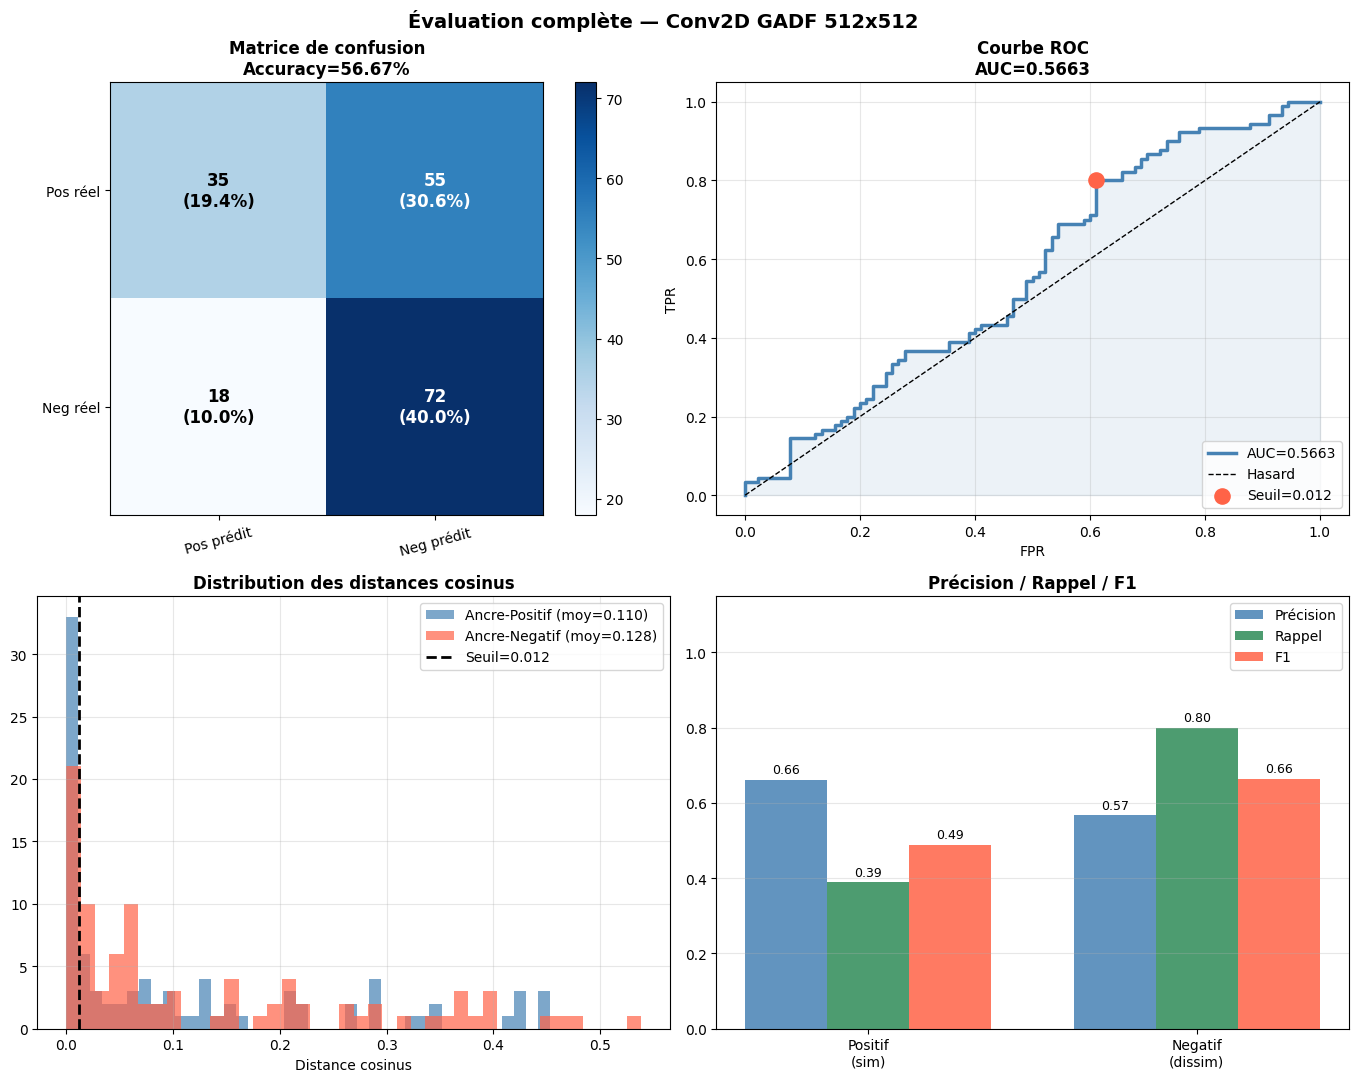

✅ Figures sauvegardées

  INTERPRÉTATION — Conv2D GADF 512x512
  Accuracy : 0.5667  →  ❌ Insuffisant
  F1-score : 0.5766  →  ❌ Insuffisant
  AUC      : 0.5663  →  ❌ Insuffisant
  ⚠️  → Vérifier que les images sont bien générées avec PAA
✅ Terminé — Mémoire libérée


In [32]:
# ════════════════════════════════════════════════
# Modèle 4 — GADF 512×512
# ════════════════════════════════════════════════
METHOD, SIZE = 'GADF', 512
IMG_SHAPE    = (SIZE, SIZE, 1)
MODEL_NAME   = f'Conv2D {METHOD} {SIZE}x{SIZE}'
print(f'\n{"="*50}\n  {MODEL_NAME}\n{"="*50}')

imgs = {
    0: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/normal', SIZE),
    1: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/irf',    SIZE),
    2: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/orf',    SIZE)
}
print(f'Shape : {imgs[0].shape}')

ancres, positifs, negatifs = create_triplets(imgs, n_triplets=TRIPLET_CONFIG[SIZE])
idx = np.arange(len(ancres))
idx_tr,idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_v, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
A_tr=ancres[idx_tr]; P_tr=positifs[idx_tr]; N_tr=negatifs[idx_tr]; y_tr=np.zeros(len(idx_tr))
A_v =ancres[idx_v];  P_v =positifs[idx_v];  N_v =negatifs[idx_v];  y_v =np.zeros(len(idx_v))
A_te=ancres[idx_te]; P_te=positifs[idx_te]; N_te=negatifs[idx_te]
print(f'Train:{len(y_tr)} | Val:{len(y_v)} | Test:{len(A_te)}')

enc  = build_encoder_2d(IMG_SHAPE)
siam = build_siamese_triplet(enc, IMG_SHAPE)
siam.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=triplet_loss(MARGIN_T))

hist = siam.fit(
    [A_tr,P_tr,N_tr], y_tr,
    validation_data=([A_v,P_v,N_v], y_v),
    epochs=EPOCHS, batch_size=BATCH_CONFIG[SIZE],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(DRIVE+f'best_{METHOD}_{SIZE}.h5', monitor='val_loss', save_best_only=True)
    ], verbose=1
)

plot_learning_curves(hist, MODEL_NAME)
acc,f1,roc_auc = evaluate_triplet(enc, A_te, P_te, N_te, MODEL_NAME)
interpret_results(acc, f1, roc_auc, MODEL_NAME)
all_results[f'{METHOD}_{SIZE}'] = {'acc':acc,'f1':f1,'auc':roc_auc}
enc.save(DRIVE + f'encoder_{METHOD}_{SIZE}.h5')

del imgs,ancres,positifs,negatifs,A_tr,P_tr,N_tr,A_v,P_v,N_v,A_te,P_te,N_te,enc,siam,hist
gc.collect(); tf.keras.backend.clear_session()
print('✅ Terminé — Mémoire libérée')

In [ ]:
# ════════════════════════════════════════════════
# Modèle 5 — GASF 1024×1024
# ⚠️  batch_size=4 pour limiter la RAM
# ════════════════════════════════════════════════
METHOD, SIZE = 'GASF', 1024
IMG_SHAPE    = (SIZE, SIZE, 1)
MODEL_NAME   = f'Conv2D {METHOD} {SIZE}x{SIZE}'
print(f'\n{"="*50}\n  {MODEL_NAME}\n{"="*50}')

imgs = {
    0: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/normal', SIZE),
    1: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/irf',    SIZE),
    2: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/orf',    SIZE)
}
print(f'Shape : {imgs[0].shape}')

ancres, positifs, negatifs = create_triplets(imgs, n_triplets=TRIPLET_CONFIG[SIZE])
idx = np.arange(len(ancres))
idx_tr,idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_v, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
A_tr=ancres[idx_tr]; P_tr=positifs[idx_tr]; N_tr=negatifs[idx_tr]; y_tr=np.zeros(len(idx_tr))
A_v =ancres[idx_v];  P_v =positifs[idx_v];  N_v =negatifs[idx_v];  y_v =np.zeros(len(idx_v))
A_te=ancres[idx_te]; P_te=positifs[idx_te]; N_te=negatifs[idx_te]
print(f'Train:{len(y_tr)} | Val:{len(y_v)} | Test:{len(A_te)}')

enc  = build_encoder_2d(IMG_SHAPE)
siam = build_siamese_triplet(enc, IMG_SHAPE)
siam.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=triplet_loss(MARGIN_T))

hist = siam.fit(
    [A_tr,P_tr,N_tr], y_tr,
    validation_data=([A_v,P_v,N_v], y_v),
    epochs=EPOCHS, batch_size=BATCH_CONFIG[SIZE],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(DRIVE+f'best_{METHOD}_{SIZE}.h5', monitor='val_loss', save_best_only=True)
    ], verbose=1
)

plot_learning_curves(hist, MODEL_NAME)
acc,f1,roc_auc = evaluate_triplet(enc, A_te, P_te, N_te, MODEL_NAME)
interpret_results(acc, f1, roc_auc, MODEL_NAME)
all_results[f'{METHOD}_{SIZE}'] = {'acc':acc,'f1':f1,'auc':roc_auc}
enc.save(DRIVE + f'encoder_{METHOD}_{SIZE}.h5')

del imgs,ancres,positifs,negatifs,A_tr,P_tr,N_tr,A_v,P_v,N_v,A_te,P_te,N_te,enc,siam,hist
gc.collect(); tf.keras.backend.clear_session()
print('✅ Terminé — Mémoire libérée')


  Conv2D GASF 1024x1024
Shape : (100, 1024, 1024, 1)


In [ ]:
# ════════════════════════════════════════════════
# Modèle 6 — GADF 1024×1024
# ════════════════════════════════════════════════
METHOD, SIZE = 'GADF', 1024
IMG_SHAPE    = (SIZE, SIZE, 1)
MODEL_NAME   = f'Conv2D {METHOD} {SIZE}x{SIZE}'
print(f'\n{"="*50}\n  {MODEL_NAME}\n{"="*50}')

imgs = {
    0: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/normal', SIZE),
    1: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/irf',    SIZE),
    2: load_images_folder(f'/content/{METHOD}_{SIZE}_paa/orf',    SIZE)
}
print(f'Shape : {imgs[0].shape}')

ancres, positifs, negatifs = create_triplets(imgs, n_triplets=TRIPLET_CONFIG[SIZE])
idx = np.arange(len(ancres))
idx_tr,idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_v, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)
A_tr=ancres[idx_tr]; P_tr=positifs[idx_tr]; N_tr=negatifs[idx_tr]; y_tr=np.zeros(len(idx_tr))
A_v =ancres[idx_v];  P_v =positifs[idx_v];  N_v =negatifs[idx_v];  y_v =np.zeros(len(idx_v))
A_te=ancres[idx_te]; P_te=positifs[idx_te]; N_te=negatifs[idx_te]
print(f'Train:{len(y_tr)} | Val:{len(y_v)} | Test:{len(A_te)}')

enc  = build_encoder_2d(IMG_SHAPE)
siam = build_siamese_triplet(enc, IMG_SHAPE)
siam.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=triplet_loss(MARGIN_T))

hist = siam.fit(
    [A_tr,P_tr,N_tr], y_tr,
    validation_data=([A_v,P_v,N_v], y_v),
    epochs=EPOCHS, batch_size=BATCH_CONFIG[SIZE],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(DRIVE+f'best_{METHOD}_{SIZE}.h5', monitor='val_loss', save_best_only=True)
    ], verbose=1
)

plot_learning_curves(hist, MODEL_NAME)
acc,f1,roc_auc = evaluate_triplet(enc, A_te, P_te, N_te, MODEL_NAME)
interpret_results(acc, f1, roc_auc, MODEL_NAME)
all_results[f'{METHOD}_{SIZE}'] = {'acc':acc,'f1':f1,'auc':roc_auc}
enc.save(DRIVE + f'encoder_{METHOD}_{SIZE}.h5')

del imgs,ancres,positifs,negatifs,A_tr,P_tr,N_tr,A_v,P_v,N_v,A_te,P_te,N_te,enc,siam,hist
gc.collect(); tf.keras.backend.clear_session()
print('✅ Terminé — Mémoire libérée')

---
# Partie 8 — Comparaison finale Conv1D vs Conv2D

In [ ]:
# Ajouter Conv1D aux résultats
all_results['Conv1D'] = {'acc': acc_1d, 'f1': f1_1d, 'auc': auc_1d}

# ── Tableau texte ─────────────────────────────────────────────────────────────
print(f"{'='*60}")
print(f"{'Modèle':<30} {'Accuracy':>10} {'F1':>8} {'AUC':>8}")
print('-'*60)
order = ['Conv1D','GASF_224','GADF_224','GASF_512','GADF_512','GASF_1024','GADF_1024']
labels_map = {
    'Conv1D'   : 'Conv1D (signaux PAA)',
    'GASF_224' : 'Conv2D GASF 224×224',
    'GADF_224' : 'Conv2D GADF 224×224',
    'GASF_512' : 'Conv2D GASF 512×512',
    'GADF_512' : 'Conv2D GADF 512×512',
    'GASF_1024': 'Conv2D GASF 1024×1024',
    'GADF_1024': 'Conv2D GADF 1024×1024',
}
for key in order:
    if key in all_results:
        r = all_results[key]
        print(f"{labels_map[key]:<30} {r['acc']*100:>9.2f}% {r['f1']:>8.4f} {r['auc']:>8.4f}")
print(f"{'='*60}")

# ── Graphe comparatif ─────────────────────────────────────────────────────────
keys_avail = [k for k in order if k in all_results]
labels     = [labels_map[k].replace(' ',  '\n') for k in keys_avail]
accs       = [all_results[k]['acc'] for k in keys_avail]
f1s        = [all_results[k]['f1']  for k in keys_avail]
aucs       = [all_results[k]['auc'] for k in keys_avail]

x = np.arange(len(keys_avail))
w = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
b1 = ax.bar(x-w, accs, width=w, label='Accuracy', color='steelblue', alpha=0.85)
b2 = ax.bar(x,   f1s,  width=w, label='F1-score', color='seagreen',  alpha=0.85)
b3 = ax.bar(x+w, aucs, width=w, label='AUC',      color='tomato',    alpha=0.85)
for bars in [b1,b2,b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score')
ax.set_title('Comparaison finale — Conv1D vs Conv2D (GASF & GADF × 3 tailles)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0.8, color='gray', linestyle=':', lw=1.5, label='Seuil 80%')
plt.tight_layout()
plt.savefig(DRIVE + 'comparaison_finale.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Comparaison sauvegardée')

---
## Conclusion

| Étape | Résultat |
|---|---|
| Signaux chargés | 100/classe × 100 000 pts |
| Normalisation | Min-Max ligne par ligne → [0,1] |
| PAA | 100 000 → 224/512/1024 pts selon taille |
| GASF + GADF | 3 tailles × 2 méthodes = 1800 images |
| Conv1D | Contrastive Loss + Distance Euclidienne |
| Conv2D × 6 | Triplet Loss + Distance Cosinus |
| Évaluation | Accuracy · F1 · AUC · Confusion · ROC |